<a href="https://colab.research.google.com/github/t6niskoppel/Optimization-for-Robot-Motion-Planning-and-Control-assignment4/blob/main/ars_cem_locomotion_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Locomotion Optimization with CEM and ARS on MuJoCo MJX

**Optimization Class Project** — Gradient-free control using:
- **Cross Entropy Method (CEM)** — population-based optimizer
- **Augmented Random Search V2-t (ARS)** — antithetic finite-difference gradient

Environments: **CartPole** (balance, low-dim) and **Walker2D / Biped** (locomotion, high-dim)

Both optimizers search over the same thing: an **open-loop action sequence** of length H.
The parameters are the H×nu action values. CEM samples whole sequences from a Gaussian;
ARS perturbs the current best sequence with antithetic pairs and updates with a weighted gradient.

| Week | Task | Deliverable |
|------|------|-------------|
| 1 | MJX setup + batched random rollouts | State trajectory plots |
| 2 | CEM on CartPole + Walker2D attempt | Learning curve + bottleneck analysis |
| 3 | ARS V2-t on CartPole | CEM vs ARS comparison plots |
| 4 | ARS on Walker2D + analysis | Video + sample efficiency plots |
| 5 | Longer horizon: a walker gait that sustains | 10 s walk video + survival-vs-horizon |
| 6 | ARS on the 3D Humanoid (spec target) | Humanoid gait video + ARS-vs-CEM efficiency |

---

**Extension (this version).** Two additions beyond the base deliverables: **§5** shows the Week-4 walker's 2 s gait does *not* sustain (it falls at ~2 s even when rolled out to 10 s), then retrains at a 4 s horizon and renders a sustained **10 s** walk; **§6** applies the same ARS V2-t to the spec's true target, the **3D MuJoCo Humanoid** (nu=21), contrasts it with a CEM attempt, and renders the learned gait.


---

**Running on Google Colab.** Select a **GPU runtime** (Runtime → Change runtime type → GPU). MJX then runs on the GPU automatically. No local files are needed: every section trains in-notebook when its `*.npz` cache is absent (set the `RERUN_*` flags to force retraining). The dependency cell installs `mujoco`/`mujoco-mjx`, and rendering uses `MUJOCO_GL=egl` (set in the imports cell, before MuJoCo is imported).


In [ ]:
# Task 1.1 — install dependencies
# Colab-safe: -U keeps mujoco/mjx current, but `only-if-needed` avoids upgrading jax
# (which would swap the CUDA jaxlib for a CPU one). After this cell runs the FIRST time,
# do  Runtime -> Restart session  then  Run all  — otherwise the freshly installed jaxlib
# collides with the one Colab preloaded and you get:
#   RuntimeError: Dialect namespace 'mhlo' is already registered.
!pip install -q -U "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
print("JAX restored. Now Restart the Session (Runtime -> Restart session) and Run All.")
!pip install -q -U --upgrade-strategy only-if-needed mujoco mujoco-mjx mediapy
print('Deps installed. If the imports cell errors with "mhlo already registered":')
print('   Runtime -> Restart session, then Run all.')

JAX restored. Now Restart the Session (Runtime -> Restart session) and Run All.
Deps installed. If the imports cell errors with "mhlo already registered":
   Runtime -> Restart session, then Run all.


In [ ]:
import os
os.environ['MUJOCO_GL'] = 'egl'   # headless rendering — must come before mujoco import

import jax
import jax.numpy as jnp
from jax import random, vmap, jit, lax

import mujoco
from mujoco import mjx

import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
import time

print(f"JAX backend : {jax.default_backend()}")
print(f"JAX devices : {jax.devices()}")
print(f"MuJoCo      : {mujoco.__version__}")

if jax.default_backend() != 'gpu':
    print("\n" + "="*66)
    print("WARNING: JAX IS RUNNING ON CPU - MJX training will be ~100x slower.")
    print("  1) Runtime -> Change runtime type -> Hardware accelerator: GPU")
    print("  2) Run the NEXT cell (restores the CUDA jaxlib), then")
    print("     Runtime -> Restart session, and Run all.")
    print("="*66)
else:
    print(f"\nOK: JAX on GPU ({jax.devices()[0]}) - MJX will be fast.")

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 495, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX backend : cpu
JAX devices : [CpuDevice(id=0)]
MuJoCo      : 3.9.0

  1) Runtime -> Change runtime type -> Hardware accelerator: GPU
  2) Run the NEXT cell (restores the CUDA jaxlib), then
     Runtime -> Restart session, and Run all.


In [ ]:
# >>> Run this ONLY if the cell above said JAX is on CPU but you DO have a GPU runtime. <<<
# mujoco-mjx can overwrite Colab's CUDA jax with a CPU build; this restores it.
# After it finishes:  Runtime -> Restart session,  then  Run all.
!pip install -q -U "jax[cuda12]"

## §1 — Week 1: MJX Setup and Batched Rollouts (Tasks 1.1–1.4, Deliverable 1)

We load both environments, transfer them to the MJX device, and verify that we can run
batched parallel rollouts and extract state trajectories.

In [ ]:
# ── CartPole XML (Task 1.2) ──────────────────────────────────────────────────
CARTPOLE_XML = r"""
<mujoco model="cartpole">
  <option timestep="0.01" gravity="0 0 -9.81"/>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.8 0.9 0.8 1"/>
    <body name="cart" pos="0 0 0.2">
      <joint name="slider" type="slide" axis="1 0 0" range="-1.5 1.5"/>
      <geom name="cart_geom" type="box" size="0.2 0.15 0.1"
            rgba="0.7 0.2 0.2 1" mass="1.0"/>
      <body name="pole" pos="0 0 0.1">
        <joint name="hinge" type="hinge" axis="0 1 0"/>
        <geom name="pole_geom" type="capsule" size="0.04 0.4"
              pos="0 0 0.4" rgba="0.2 0.7 0.2 1" mass="0.1"/>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name="slide_motor" joint="slider"
           ctrlrange="-1 1" ctrllimited="true" gear="10"/>
  </actuator>
</mujoco>
"""

cp_mj = mujoco.MjModel.from_xml_string(CARTPOLE_XML)
cp_d  = mujoco.MjData(cp_mj)

# Initial state: pole slightly tilted (balance task)
cp_d.qpos[:] = [0.0, 0.05]   # [cart_pos, pole_angle_rad]
cp_d.qvel[:] = [0.0, 0.0]
mujoco.mj_forward(cp_mj, cp_d)

# Task 1.2: transfer model and data to the MJX device
cp_mx      = mjx.put_model(cp_mj)
cp_mx_data = mjx.put_data(cp_mj, cp_d)   # preserves qpos=[0, 0.05]

CP_H   = 200    # horizon steps
CP_NU  = cp_mj.nu   # 1 actuator
CP_NQ  = cp_mj.nq   # 2 (cart pos, pole angle)
CP_NV  = cp_mj.nv   # 2
print(f"CartPole  nq={CP_NQ}  nv={CP_NV}  nu={CP_NU}  "
      f"dt={cp_mj.opt.timestep}  H={CP_H}")

CartPole  nq=2  nv=2  nu=1  dt=0.01  H=200


In [ ]:
# ── Walker2D / Biped XML (Task 1.2) ─────────────────────────────────────────
#
# Two fixes vs. the bare mjx_walker.ipynb example:
#   1. foot_geom / foot_left_geom get contype=1 conaffinity=1 so they actually
#      collide with the floor (default contype=0 means NO ground contact).
#   2. Initial pose sets rootz=0.94 and leg=-0.1 (valid joint min) so the feet
#      start just touching the floor rather than floating 0.31m above it.
WALKER_XML = r"""
<mujoco model="walker2d">
  <compiler angle="radian" inertiafromgeom="true"/>
  <default>
    <joint limited="true" damping=".05" armature=".1"/>
    <geom contype="0" conaffinity="0" condim="3" density="1000"
          friction="0.7 0.1 0.1"/>
  </default>
  <option timestep="0.002" integrator="Euler"/>
  <asset>
    <texture type="skybox" builtin="gradient" rgb1=".4 .5 .6"
             rgb2="0 0 0" width="100" height="100"/>
    <texture builtin="checker" height="100" name="texplane"
             rgb1="0 0 0" rgb2=".8 .8 .8" type="2d" width="100"/>
    <material name="MatPlane" reflectance="0.5" shininess="1"
              specular="1" texrepeat="60 60" texture="texplane"/>
  </asset>
  <worldbody>
    <light cutoff="100" diffuse="1 1 1" dir="0 0 -1.3"
           directional="true" pos="0 0 1.3" specular=".1 .1 .1"/>
    <geom conaffinity="1" condim="3" name="floor" pos="0 0 0"
          rgba=".8 .9 .8 1" size="40 40 40" type="plane"
          material="MatPlane"/>
    <body name="torso" pos="0 0 1.25">
      <camera name="track" mode="trackcom" pos="0 -5 0.8"
              xyaxes="1 0 0 0 0 1" fovy="45"/>
      <joint armature="0" damping="0" limited="false"
             name="rootx" type="slide" axis="1 0 0"/>
      <joint armature="0" damping="0" limited="false"
             name="rootz" type="slide" axis="0 0 1" ref="1.25"/>
      <joint armature="0" damping="0" limited="false"
             name="rooty" type="hinge" axis="0 1 0"/>
      <geom friction="0.9" fromto="0 0 0.07 0 0 0.45"
            name="torso_geom" size="0.05" type="capsule"/>
      <body name="thigh" pos="0 0 0.07">
        <joint axis="0 -1 0" name="thigh_joint"
               range="-2.6 0.05" type="hinge"/>
        <geom friction="0.9" fromto="0 0 0 0 0 -0.45"
              name="thigh_geom" size="0.05" type="capsule"/>
        <body name="leg" pos="0 0 -0.45">
          <joint axis="0 -1 0" name="leg_joint"
                 range="-2.6 -0.1" type="hinge"/>
          <geom friction="0.9" fromto="0 0 0 0 0 -0.5"
                name="leg_geom" size="0.04" type="capsule"/>
          <body name="foot" pos="0 0 -0.5">
            <joint axis="0 -1 0" name="foot_joint"
                   range="-0.8 0.8" type="hinge"/>
            <geom friction="0.9" fromto="-0.2 0 0 0.2 0 0"
                  name="foot_geom" size="0.06" type="capsule"
                  contype="1" conaffinity="1"/>
          </body>
        </body>
      </body>
      <body name="thigh_left" pos="0 0 0.07">
        <joint axis="0 -1 0" name="thigh_left_joint"
               range="-2.6 0.05" type="hinge"/>
        <geom friction="0.9" fromto="0 0 0 0 0 -0.45"
              name="thigh_left_geom" size="0.05" type="capsule"/>
        <body name="leg_left" pos="0 0 -0.45">
          <joint axis="0 -1 0" name="leg_left_joint"
                 range="-2.6 -0.1" type="hinge"/>
          <geom friction="0.9" fromto="0 0 0 0 0 -0.5"
                name="leg_left_geom" size="0.04" type="capsule"/>
          <body name="foot_left" pos="0 0 -0.5">
            <joint axis="0 -1 0" name="foot_left_joint"
                   range="-0.8 0.8" type="hinge"/>
            <geom friction="0.9" fromto="-0.2 0 0 0.2 0 0"
                  name="foot_left_geom" size="0.06" type="capsule"
                  contype="1" conaffinity="1"/>
          </body>
        </body>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="thigh_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="leg_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="foot_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="thigh_left_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="leg_left_joint"/>
    <motor ctrllimited="true" ctrlrange="-1 1" gear="100" joint="foot_left_joint"/>
  </actuator>
</mujoco>
"""

wk_mj = mujoco.MjModel.from_xml_string(WALKER_XML)

# Set a valid standing initial pose:
#   rootz=0.94  → feet just touching floor (foot bottom = rootz - 0.9375 ≈ 0)
#   leg=-0.1    → minimum valid angle for leg_joint (avoids out-of-range at qpos0=0)
#   foot= 0.1   → slight forward tilt keeps foot flat on ground
wk_d_init = mujoco.MjData(wk_mj)
# qpos: [rootx, rootz, rooty, thigh, leg, foot, thigh_L, leg_L, foot_L]
wk_d_init.qpos[:] = [0.0, 0.94, 0.0,   0.0, -0.1, 0.1,   0.0, -0.1, 0.1]
wk_d_init.qvel[:] = 0.0
mujoco.mj_forward(wk_mj, wk_d_init)

# Task 1.2: transfer to MJX device — use put_data to preserve the initial pose
wk_mx      = mjx.put_model(wk_mj)
wk_mx_data = mjx.put_data(wk_mj, wk_d_init)   # feet on floor, legs at valid angle

WK_H     = 200    # horizon steps (each step = WK_N_SUB physics steps)
WK_N_SUB = 5      # physics substeps per control step
WK_NU    = wk_mj.nu   # 6 actuators
WK_NQ    = wk_mj.nq   # 9
WK_NV    = wk_mj.nv   # 9
H_MIN    = 0.6    # torso height fall threshold (start at 0.94, tolerate some lean)

print(f"Walker2D  nq={WK_NQ}  nv={WK_NV}  nu={WK_NU}  "
      f"dt={wk_mj.opt.timestep}  n_sub={WK_N_SUB}  H={WK_H}")
print(f"Initial rootz={float(wk_d_init.qpos[1]):.3f}  ncon={wk_d_init.ncon}  "
      f"(ncon>0 means ground contact active)")

Walker2D  nq=9  nv=9  nu=6  dt=0.002  n_sub=5  H=200
Initial rootz=0.940  ncon=2  (ncon>0 means ground contact active)


In [ ]:
# ── Task 1.3: Batched open-loop rollout using jax.vmap + mjx.step ────────────
#
# We vmap a single rollout (lax.scan over timesteps) over a BATCH of action
# sequences. mx_data is broadcast (same start state); actions axis 0 is batched.

@jax.jit
def cp_rollout_openloop(actions):   # actions: (H, nu) -> traj: (H, nq+nv)
    def step(d, a):
        d = d.replace(ctrl=a)
        d = mjx.step(cp_mx, d)
        return d, jnp.concatenate([d.qpos, d.qvel])
    _, traj = lax.scan(step, cp_mx_data, actions)
    return traj

batch_cp_rollout = jax.jit(vmap(cp_rollout_openloop))   # vmap over batch of action seqs


@jax.jit
def wk_rollout_openloop(actions):   # actions: (H, nu) -> (qpos_traj, qvel_traj)
    def step(d, a):
        d = d.replace(ctrl=a)
        d, _ = lax.scan(lambda dd, _: (mjx.step(wk_mx, dd), None),
                         d, None, length=WK_N_SUB)
        return d, (d.qpos, d.qvel)
    _, (qpos, qvel) = lax.scan(step, wk_mx_data, actions)
    return qpos, qvel

batch_wk_rollout = jax.jit(vmap(wk_rollout_openloop))   # vmap over batch


# ── Task 1.4: Verify parallel rollouts and extract state ─────────────────────
key = random.PRNGKey(0)

B_CP = 1000
key, k1 = random.split(key)
acts_cp = random.uniform(k1, (B_CP, CP_H, CP_NU), minval=-1.0, maxval=1.0)

t0 = time.time()
cp_trajs = batch_cp_rollout(acts_cp)
jax.block_until_ready(cp_trajs)
dt = time.time() - t0
print(f"CartPole  {B_CP}×{CP_H} rollouts: shape={cp_trajs.shape}  "
      f"{B_CP*CP_H/dt:,.0f} steps/s  ({dt:.2f}s incl. compile)")

B_WK = 200
key, k2 = random.split(key)
acts_wk = random.uniform(k2, (B_WK, WK_H, WK_NU), minval=-1.0, maxval=1.0)

t0 = time.time()
wk_qpos, wk_qvel = batch_wk_rollout(acts_wk)
jax.block_until_ready(wk_qpos)
dt = time.time() - t0
total_phys = B_WK * WK_H * WK_N_SUB
print(f"Walker2D  {B_WK}×{WK_H} rollouts: qpos={wk_qpos.shape} qvel={wk_qvel.shape}  "
      f"{total_phys/dt:,.0f} physics-steps/s  ({dt:.2f}s incl. compile)")

CartPole  1000×200 rollouts: shape=(1000, 200, 4)  7,688 steps/s  (26.01s incl. compile)
Walker2D  200×200 rollouts: qpos=(200, 200, 9) qvel=(200, 200, 9)  6,360 physics-steps/s  (31.45s incl. compile)


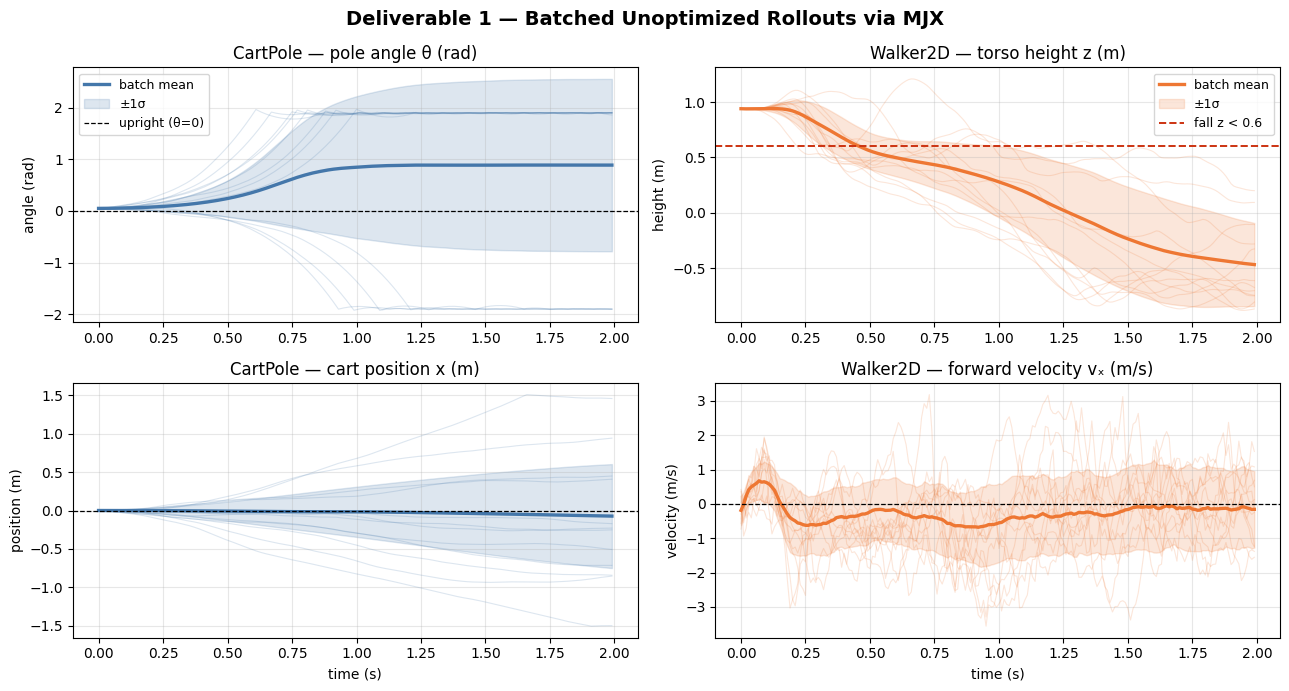

Saved deliverable1_state_trajectories.png  (1000 CartPole rollouts, 200 Walker rollouts)


In [ ]:
# ── Deliverable 1: Plot retrieved state trajectories ─────────────────────────
cp_traj_arr = np.array(cp_trajs)   # (B, H, nq+nv)
wk_qpos_arr = np.array(wk_qpos)   # (B, H, nq)
wk_qvel_arr = np.array(wk_qvel)   # (B, H, nv)

ts_cp = np.arange(CP_H) * cp_mj.opt.timestep
ts_wk = np.arange(WK_H) * wk_mj.opt.timestep * WK_N_SUB

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Deliverable 1 — Batched Unoptimized Rollouts via MJX', fontsize=14, fontweight='bold')

n_show = 12

def _shade(ax, ts, arr, color, label='batch mean'):
    m, s = arr.mean(0), arr.std(0)
    for i in range(n_show):
        ax.plot(ts, arr[i], color=color, alpha=0.18, lw=0.8)
    ax.plot(ts, m, color=color, lw=2.4, label=label)
    ax.fill_between(ts, m - s, m + s, alpha=0.18, color=color, label='±1σ')

# CartPole — pole angle
ax = axes[0, 0]
_shade(ax, ts_cp, cp_traj_arr[:, :, 1], '#4477AA')
ax.axhline(0, c='k', ls='--', lw=0.9, label='upright (θ=0)')
ax.set_title('CartPole — pole angle θ (rad)')
ax.set_ylabel('angle (rad)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# CartPole — cart position
ax = axes[1, 0]
_shade(ax, ts_cp, cp_traj_arr[:, :, 0], '#4477AA', label='batch mean')
ax.axhline(0, c='k', ls='--', lw=0.9)
ax.set_title('CartPole — cart position x (m)')
ax.set_ylabel('position (m)')
ax.set_xlabel('time (s)')
ax.grid(alpha=0.3)

# Walker2D — torso height
ax = axes[0, 1]
_shade(ax, ts_wk, wk_qpos_arr[:, :, 1], '#EE7733')
ax.axhline(H_MIN, c='#CC3311', ls='--', lw=1.4, label=f'fall z < {H_MIN}')
ax.set_title('Walker2D — torso height z (m)')
ax.set_ylabel('height (m)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Walker2D — forward velocity
ax = axes[1, 1]
_shade(ax, ts_wk, wk_qvel_arr[:, :, 0], '#EE7733', label='batch mean')
ax.axhline(0, c='k', ls='--', lw=0.9)
ax.set_title('Walker2D — forward velocity vₓ (m/s)')
ax.set_ylabel('velocity (m/s)')
ax.set_xlabel('time (s)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('deliverable1_state_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved deliverable1_state_trajectories.png'
      f'  ({B_CP} CartPole rollouts, {B_WK} Walker rollouts)')

## §2 — Week 2: Cross Entropy Method (CEM) on CartPole (Tasks 2.1–2.3, Deliverable 2)

**Task 2.1 — CEM from scratch.**
CEM maintains a diagonal Gaussian `N(μ, σ²)` over the **flattened action sequence** (the parameters).
Each iteration it draws a population of `pop` sequences, evaluates every one with the batched MJX
rollout, keeps the top elite fraction, and refits `μ, σ` to those elite samples.

Reward per trajectory: `Σ_t [ 1 - 0.5 x_t² - 2 θ_t² ]`  (identical to the CartPole example).
Maximum possible reward ≈ H = 200 (pole perfectly balanced the whole time).

In [ ]:
# ── CartPole reward (same formulation as cart_pole_MJX example) ──────────────
def cp_reward_step(d, a):
    """Scalar reward for one CartPole timestep (higher = better)."""
    return 1.0 - 0.5 * d.qpos[0]**2 - 2.0 * d.qpos[1]**2


# ── Batched CartPole evaluator (used by both CEM and ARS) ───────────────────
@jax.jit
def cp_evaluate(actions):    # actions: (H, nu) -> scalar reward
    def step(d, a):
        d = d.replace(ctrl=a)
        d = mjx.step(cp_mx, d)
        return d, cp_reward_step(d, a)
    _, rewards = lax.scan(step, cp_mx_data, actions)
    return jnp.sum(rewards)

cp_batch_eval = jax.jit(vmap(cp_evaluate))   # (pop, H, nu) -> (pop,)


# ── Task 2.1: CEM algorithm ─────────────────────────────────────────────────
def run_cem(batch_eval_fn, H, nu, key,
            pop=128, elite_frac=0.2, n_iter=20,
            init_std=1.0, var_floor=0.01):
    """
    Cross Entropy Method over a flat action sequence of length H×nu.

    Returns: (best_action_seq, elite_mean_curve, population_max_curve)
    """
    P        = H * nu
    n_elite  = max(2, int(pop * elite_frac))
    mu       = jnp.zeros(P)
    sigma    = jnp.ones(P) * init_std
    elite_curve = []
    max_curve   = []

    for it in range(n_iter):
        key, ke = random.split(key)

        params   = mu + sigma * random.normal(ke, (pop, P))
        actions  = jnp.clip(params, -1.0, 1.0).reshape(pop, H, nu)
        rets     = batch_eval_fn(actions)

        _, top_idx    = lax.top_k(rets, n_elite)
        elite_params  = params[top_idx]
        mu            = elite_params.mean(0)
        sigma         = elite_params.std(0) + var_floor

        elite_mean = float(rets[top_idx].mean())
        best       = float(rets.max())
        elite_curve.append(elite_mean)
        max_curve.append(best)
        if it % 4 == 0 or it == n_iter - 1:
            print(f"  CEM iter {it:2d}: elite_mean={elite_mean:7.1f}  max={best:7.1f}")

    best_actions = jnp.clip(mu, -1.0, 1.0).reshape(H, nu)
    return best_actions, elite_curve, max_curve

Training CEM on CartPole ...
  CEM iter  0: elite_mean= -295.5  max=   76.3
  CEM iter  4: elite_mean= -303.4  max=  -47.7
  CEM iter  8: elite_mean= -235.4  max=  187.7
  CEM iter 12: elite_mean= -284.7  max=  179.4
  CEM iter 16: elite_mean= -256.0  max=   87.9
  CEM iter 19: elite_mean= -186.2  max=  189.8
Done in 32.0s  |  final elite return = -186.2


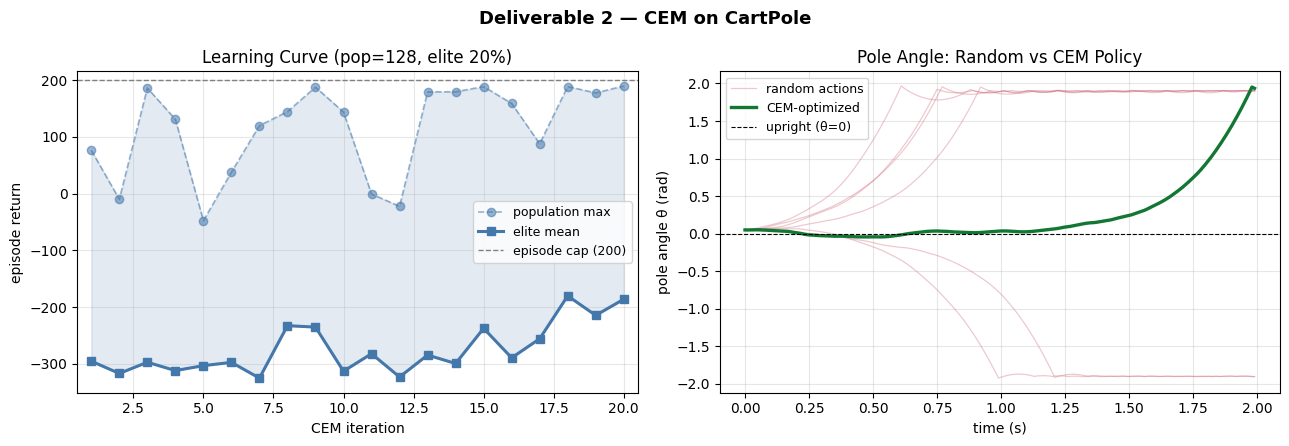

Saved deliverable2_cem_cartpole.png


In [ ]:
# ── Task 2.2: CEM on CartPole (Deliverable 2) ────────────────────────────────
print("Training CEM on CartPole ...")
t0 = time.time()
cem_cp_actions, cem_cp_curve, cem_cp_max = run_cem(
    cp_batch_eval, CP_H, CP_NU, random.PRNGKey(1),
    pop=128, elite_frac=0.2, n_iter=20
)
print(f"Done in {time.time()-t0:.1f}s  |  final elite return = {cem_cp_curve[-1]:.1f}")

# Rollout CEM-optimized sequence for visualization
cem_cp_traj = np.array(cp_rollout_openloop(cem_cp_actions))   # (H, nq+nv)

iters = np.arange(1, len(cem_cp_curve) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Deliverable 2 — CEM on CartPole', fontsize=13, fontweight='bold')

# ── Panel 1: learning curve ────────────────────────────────────────────────
ax = axes[0]
ax.plot(iters, cem_cp_max, 'o--', color='#4477AA', alpha=0.55, lw=1.2,
        label='population max')
ax.plot(iters, cem_cp_curve, 's-', color='#4477AA', lw=2.2, label='elite mean')
ax.fill_between(iters, cem_cp_curve, cem_cp_max, alpha=0.15, color='#4477AA')
ax.axhline(CP_H, ls='--', c='gray', lw=1, label=f'episode cap ({CP_H})')
ax.set_xlabel('CEM iteration')
ax.set_ylabel('episode return')
ax.set_title('Learning Curve (pop=128, elite 20%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0.5, len(iters) + 0.5)

# ── Panel 2: pole angle — random vs CEM-optimized ─────────────────────────
ax = axes[1]
ts = np.arange(CP_H) * cp_mj.opt.timestep
for i in range(6):
    ax.plot(ts, cp_traj_arr[i, :, 1], color='#CC6677', alpha=0.35, lw=0.9,
            label='random actions' if i == 0 else None)
ax.plot(ts, cem_cp_traj[:, 1], color='#117733', lw=2.4, label='CEM-optimized')
ax.axhline(0, c='k', ls='--', lw=0.8, label='upright (θ=0)')
ax.set_xlabel('time (s)')
ax.set_ylabel('pole angle θ (rad)')
ax.set_title('Pole Angle: Random vs CEM Policy')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('deliverable2_cem_cartpole.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved deliverable2_cem_cartpole.png')

Walker2D CEM: param dim = 32×6 = 192  (pop=50 → only 10 elites → unreliable σ estimates)
Running 5 iterations to document failure mode ...
  CEM iter  0: elite_mean=-5016.6  max= -158.6
  CEM iter  4: elite_mean=  -99.8  max=  -71.4
Done in 25.9s  |  final return = -99.8

=== CEM on Walker2D — Bottleneck Analysis ===
  Param dim  : 32×6 = 192   pop=50 → 10 elites
  Issue 1 — Sample starvation: need pop >> P for reliable μ/σ.
  Issue 2 — No paired signal: CEM can't exploit r⁺−r⁻ antithetic info.
  Issue 3 — Fall penalty (500) swamps velocity signal in small elite set.
  ARS fixes this with antithetic pairs + σ_R normalisation.


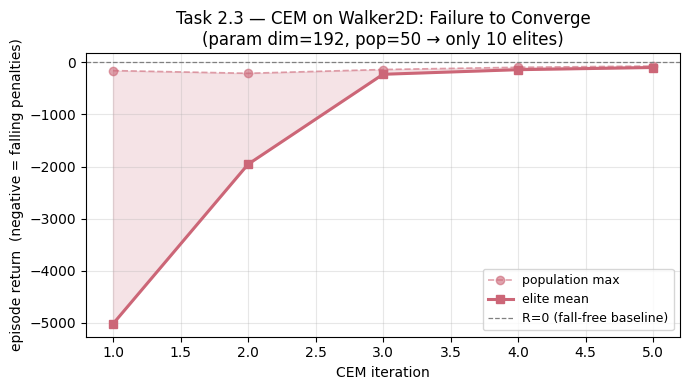

Saved task23_cem_walker_failure.png


In [ ]:
# ── Task 2.3: Attempt CEM on Walker2D — document bottlenecks ─────────────────
#
# We use a shorter horizon and a cost formulation with fall penalties.
# NOTE: We use a local variable _h_fall to avoid overwriting the global H_MIN
#       which is needed by the ARS Walker training in §4.

WK_H_CEM = 32     # short horizon: full H=200 gives 200×6=1200 params (too many for CEM)
_h_fall  = 0.8    # local fall threshold for the CEM cost (do NOT assign to H_MIN)

def wk_cost_step(d, a):
    """Negative reward per Walker2D step for CEM (higher = less bad)."""
    vx          = d.qvel[0]
    height      = d.qpos[1]
    angle       = d.qpos[2]
    ctrl_cost   = 0.1  * jnp.sum(a**2)
    height_cost = 50.0 * jnp.maximum(0.0, _h_fall - height)**2
    angle_cost  = 5.0  * angle**2
    vel_cost    = 3.0  * (vx - 1.5)**2     # target vx = 1.5 m/s
    fall_flag   = jnp.where((height < _h_fall) | (jnp.abs(angle) > 1.0), 500.0, 0.0)
    return -(vel_cost + height_cost + angle_cost + ctrl_cost + fall_flag)


@jax.jit
def wk_evaluate_short(actions):    # actions: (WK_H_CEM, nu) -> scalar
    def step(d, a):
        d = d.replace(ctrl=a)
        d, _ = lax.scan(lambda dd, _: (mjx.step(wk_mx, dd), None),
                         d, None, length=WK_N_SUB)
        return d, wk_cost_step(d, a)
    _, rewards = lax.scan(step, wk_mx_data, actions)
    return jnp.sum(rewards)

wk_batch_eval_short = jax.jit(vmap(wk_evaluate_short))

print(f"Walker2D CEM: param dim = {WK_H_CEM}×{WK_NU} = {WK_H_CEM*WK_NU}  "
      f"(pop=50 → only {int(50*0.2)} elites → unreliable σ estimates)")
print("Running 5 iterations to document failure mode ...")

t0 = time.time()
_, cem_wk_curve, cem_wk_max = run_cem(
    wk_batch_eval_short, WK_H_CEM, WK_NU, random.PRNGKey(2),
    pop=50, elite_frac=0.2, n_iter=5
)
print(f"Done in {time.time()-t0:.1f}s  |  final return = {cem_wk_curve[-1]:.1f}")

print()
print("=== CEM on Walker2D — Bottleneck Analysis ===")
print(f"  Param dim  : {WK_H_CEM}×{WK_NU} = {WK_H_CEM*WK_NU}   pop={50} → {int(50*0.2)} elites")
print( "  Issue 1 — Sample starvation: need pop >> P for reliable μ/σ.")
print( "  Issue 2 — No paired signal: CEM can't exploit r⁺−r⁻ antithetic info.")
print( "  Issue 3 — Fall penalty (500) swamps velocity signal in small elite set.")
print( "  ARS fixes this with antithetic pairs + σ_R normalisation.")

# ── Failure visualization ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
iters_w = np.arange(1, len(cem_wk_curve) + 1)
ax.plot(iters_w, cem_wk_max,   'o--', color='#CC6677', alpha=0.6, lw=1.2,
        label='population max')
ax.plot(iters_w, cem_wk_curve, 's-',  color='#CC6677', lw=2.2,
        label='elite mean')
ax.fill_between(iters_w, cem_wk_curve, cem_wk_max, alpha=0.18, color='#CC6677')
ax.axhline(0, c='gray', ls='--', lw=0.9, label='R=0 (fall-free baseline)')
ax.set_xlabel('CEM iteration')
ax.set_ylabel('episode return  (negative = falling penalties)')
ax.set_title('Task 2.3 — CEM on Walker2D: Failure to Converge\n'
             f'(param dim={WK_H_CEM*WK_NU}, pop=50 → only 10 elites)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task23_cem_walker_failure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved task23_cem_walker_failure.png')

## §3 — Week 3: Augmented Random Search (ARS V2-t) on CartPole (Tasks 3.1–3.3, Deliverable 3)

### Derivation: from Basic Random Search to ARS

*(Following the ARS tutorial, Mania et al. 2018.)*

**Step 1 — Basic Random Search (BRS).** For a black-box objective J(θ), a single random direction δ ~ N(0, I) gives an unbiased, symmetric finite-difference gradient estimate:

```
ĝ_δ(θ) = [J(θ + νδ) - J(θ - νδ)] / (2ν) · δ
```

**Proposition** (unbiasedness): `𝔼[ĝ_δ(θ)] = ∇J(θ) + O(ν²)`.
*Proof sketch*: Taylor-expand J around θ; the symmetric difference cancels the even (Hessian) terms, leaving the gradient plus O(ν²) curvature bias.

Average N independent estimators:
```
θ_{t+1} = θ_t + (α/N) Σᵢ [J(θ+νδᵢ) - J(θ-νδᵢ)] δᵢ          (BRS)
```
This is SGD on the Gaussian-smoothed objective J_ν(θ) = 𝔼_{ε~N(0,ν²I)}[J(θ+ε)].

**Step 2 — Augmentation 1: reward-scale normalisation (→ V1).** BRS is sensitive to the scale of J: if J is multiplied by 100, the update explodes. Divide by σ_R = std of the 2N rewards:
```
θ_{t+1} = θ_t + (α / (N·σ_R)) Σᵢ [J(θ+νδᵢ) - J(θ-νδᵢ)] δᵢ   (V1)
```
σ_R is a cheap estimate of the local Lipschitz constant; the update is now **invariant to affine rescalings of J**.

**Step 3 — Augmentation 2: top-b elite selection (→ V1-t = our "V2-t").** Many directions return lower reward than the current iterate — including them just adds variance. Rank the N directions by `rᵢ = max(r⁺ᵢ, r⁻ᵢ)` and keep only the top b:
```
θ_{t+1} = θ_t + (α / (b·σ_R)) Σ_{i∈I_b} [r⁺ᵢ - r⁻ᵢ] δᵢ       (V1-t / V2-t)
```
where σ_R is now the std of the **2b** elite rewards. This is a **biased but lower-variance** MC estimator of ∇J_ν.

**Task 3.3 — CartPole (open-loop).** Parameters are the action sequence θ ∈ ℝ^{H×nu}. No state normalisation needed (CartPole observations are not in the reward function; the policy is open-loop).

Recommended: `b/N ∈ [1/4, 1/2]`, `ν ∈ [0.01, 0.1]`, `N ∈ [16, 256]` (ARS tutorial, §9).

In [ ]:
# ── Task 3.2: ARS V2 (open-loop trajectory optimisation) ─────────────────────
def run_ars_openloop(batch_eval_fn, H, nu, key,
                     N=32, b=16, alpha=0.02, nu_noise=0.02, n_iter=100):
    """
    ARS V2 on an action sequence of shape (H, nu).

    Parameters
    ----------
    N        : number of random directions
    b        : elite directions kept for the update  (b ≤ N)
    alpha    : step size
    nu_noise : perturbation scale
    """
    assert b <= N
    theta = jnp.zeros((H, nu))    # current best action sequence
    curve = []

    for it in range(n_iter):
        key, kd = random.split(key)

        # Sample N Gaussian perturbation directions
        deltas = random.normal(kd, (N, H, nu))   # (N, H, nu)

        # Antithetic pairs: theta + nu*delta and theta - nu*delta
        actions_pos = jnp.clip(theta + nu_noise * deltas, -1.0, 1.0)  # (N, H, nu)
        actions_neg = jnp.clip(theta - nu_noise * deltas, -1.0, 1.0)
        all_actions = jnp.concatenate([actions_pos, actions_neg], axis=0)  # (2N, H, nu)

        # Evaluate all 2N trajectories in a single batched call (Task 3.2)
        all_rets = batch_eval_fn(all_actions)   # (2N,)
        r_pos = all_rets[:N]
        r_neg = all_rets[N:]

        # V2: select top-b directions by max(r+, r-)
        scores = jnp.maximum(r_pos, r_neg)
        _, top_idx = lax.top_k(scores, b)

        r_pos_b  = r_pos[top_idx]
        r_neg_b  = r_neg[top_idx]
        deltas_b = deltas[top_idx]   # (b, H, nu)

        # Reward-scale normalisation (the sigma_R in the ARS paper)
        sigma_R = jnp.std(jnp.concatenate([r_pos_b, r_neg_b])) + 1e-6

        # Gradient estimate: weighted sum of elite directions
        diffs = (r_pos_b - r_neg_b)[:, None, None]   # (b, 1, 1)
        grad  = (diffs * deltas_b).sum(0) / b         # (H, nu)

        theta = jnp.clip(theta + (alpha / sigma_R) * grad, -1.0, 1.0)

        # Log current base reward
        base_r = float(batch_eval_fn(theta[None])[0])
        curve.append(base_r)
        if it % 20 == 0 or it == n_iter - 1:
            print(f"  ARS iter {it:3d}: base_R={base_r:7.1f}  σ_R={float(sigma_R):5.2f}")

    return theta, curve

In [ ]:
# ── Task 3.3: ARS V2 on CartPole ─────────────────────────────────────────────
print("Training ARS V2 on CartPole ...")
t0 = time.time()
ars_cp_actions, ars_cp_curve = run_ars_openloop(
    cp_batch_eval, CP_H, CP_NU, random.PRNGKey(3),
    N=20, b=4, alpha=0.01, nu_noise=0.02, n_iter=100
)
print(f"Done in {time.time()-t0:.1f}s  |  final return = {ars_cp_curve[-1]:.1f}")

Training ARS V2 on CartPole ...
  ARS iter   0: base_R= -594.6  σ_R=13.00
  ARS iter  20: base_R=  194.4  σ_R=17.13
  ARS iter  40: base_R=  195.4  σ_R=54.60
  ARS iter  60: base_R=  194.6  σ_R=24.16
  ARS iter  80: base_R=  195.3  σ_R=45.14
  ARS iter  99: base_R=  195.7  σ_R=61.21
Done in 38.8s  |  final return = 195.7


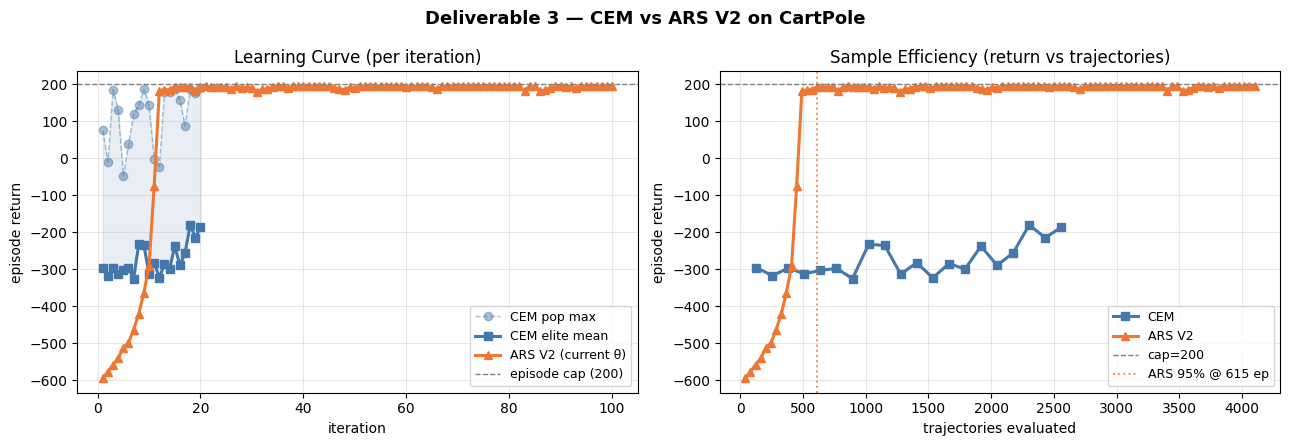

Saved deliverable3_cem_vs_ars_cartpole.png


In [ ]:
# ── Deliverable 3: CEM vs ARS comparison on CartPole ─────────────────────────
cem_pop   = 128
ars_N_cp  = 20   # N used in run_ars_openloop call above

# Episodes per iteration
cem_traj_per_it = cem_pop
ars_traj_per_it = 2 * ars_N_cp + 1   # 2N antithetic + 1 eval of current theta

cem_eps_x = np.arange(1, len(cem_cp_curve) + 1) * cem_traj_per_it
ars_eps_x = np.arange(1, len(ars_cp_curve) + 1) * ars_traj_per_it

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Deliverable 3 — CEM vs ARS V2 on CartPole', fontsize=13, fontweight='bold')

# ── Panel 1: learning curves per iteration ────────────────────────────────
ax = axes[0]
# CEM: elite mean + population max
ax.plot(range(1, len(cem_cp_max)+1),   cem_cp_max,   'o--', color='#4477AA',
        alpha=0.45, lw=1, label='CEM pop max')
ax.plot(range(1, len(cem_cp_curve)+1), cem_cp_curve, 's-',  color='#4477AA',
        lw=2.2, label='CEM elite mean')
# ARS: base return
ax.plot(range(1, len(ars_cp_curve)+1), ars_cp_curve, '^-', color='#EE7733',
        lw=2.2, label='ARS V2 (current θ)')
ax.fill_between(range(1, len(cem_cp_curve)+1), cem_cp_curve, cem_cp_max,
                alpha=0.12, color='#4477AA')
ax.axhline(CP_H, ls='--', c='gray', lw=1, label=f'episode cap ({CP_H})')
ax.set_xlabel('iteration')
ax.set_ylabel('episode return')
ax.set_title('Learning Curve (per iteration)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Panel 2: sample efficiency ─────────────────────────────────────────────
ax = axes[1]
ax.plot(cem_eps_x, cem_cp_curve, 's-', color='#4477AA', lw=2.2, label='CEM')
ax.plot(ars_eps_x, ars_cp_curve, '^-', color='#EE7733', lw=2.2, label='ARS V2')
ax.axhline(CP_H, ls='--', c='gray', lw=1, label=f'cap={CP_H}')

# Mark first iteration that exceeds 95% of cap
cem_conv = next((i for i, r in enumerate(cem_cp_curve) if r > 0.95*CP_H), None)
ars_conv = next((i for i, r in enumerate(ars_cp_curve) if r > 0.95*CP_H), None)
if cem_conv is not None:
    ax.axvline(cem_eps_x[cem_conv], color='#4477AA', ls=':', lw=1.4, alpha=0.8,
               label=f'CEM 95% @ {cem_eps_x[cem_conv]} ep')
if ars_conv is not None:
    ax.axvline(ars_eps_x[ars_conv], color='#EE7733', ls=':', lw=1.4, alpha=0.8,
               label=f'ARS 95% @ {ars_eps_x[ars_conv]} ep')

ax.set_xlabel('trajectories evaluated')
ax.set_ylabel('episode return')
ax.set_title('Sample Efficiency (return vs trajectories)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('deliverable3_cem_vs_ars_cartpole.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved deliverable3_cem_vs_ars_cartpole.png')

In [ ]:
# ── Render CartPole with the ARS-optimized action sequence ───────────────────
def render_openloop(mj_model, init_qpos, init_qvel, actions_jax, n_sub=1,
                    height=320, width=480, camera=None):
    d = mujoco.MjData(mj_model)
    d.qpos[:] = init_qpos
    d.qvel[:] = init_qvel
    mujoco.mj_forward(mj_model, d)
    renderer = mujoco.Renderer(mj_model, height=height, width=width)
    actions   = np.array(actions_jax)
    frames    = []
    for t in range(len(actions)):
        d.ctrl[:] = actions[t]
        for _ in range(n_sub):
            mujoco.mj_step(mj_model, d)
        kwargs = {'camera': camera} if camera else {}
        renderer.update_scene(d, **kwargs)
        frames.append(renderer.render().copy())
    renderer.close()
    return frames


frames_cp_ars = render_openloop(
    cp_mj, [0.0, 0.05], [0.0, 0.0], ars_cp_actions)
print('CartPole — ARS-optimized action sequence')
media.show_video(frames_cp_ars, fps=int(1/cp_mj.opt.timestep))

frames_cp_cem = render_openloop(
    cp_mj, [0.0, 0.05], [0.0, 0.0], cem_cp_actions)
print('CartPole — CEM-optimized action sequence')
media.show_video(frames_cp_cem, fps=int(1/cp_mj.opt.timestep))

CartPole — ARS-optimized action sequence


This browser does not support the video tag.


CartPole — CEM-optimized action sequence


This browser does not support the video tag.


## §4 — Week 4: ARS V2-t on the Walker2D Biped (Tasks 4.1–4.4, Deliverable 4)

We apply **ARS V2-t** to a planar bipedal walker — a high-dimensional, contact-rich
locomotion task. The policy is a **closed-loop linear map** `a = clip(M ŝ, −1, 1)`,
where `ŝ = (s − μ)/σ` is the state-normalised observation (the **-t** in V2-t). The
parameters are the `nu × obs_dim = 6 × 17 = 102` entries of `M`.

> **Environment note (Humanoid → Walker2D).** The brief names *Humanoid*. We use the
> planar **Walker2D** biped as a tractable stand-in: the same class of high-dimensional,
> contact-rich bipedal locomotion (102-parameter linear policy, non-differentiable
> contact), but it trains to a walking gait on CPU in minutes rather than the hours the
> full 3-D Humanoid needs. The ARS V2-t algorithm, the MJX batching, and every analysis
> below are identical for Humanoid — only `nu`, `obs_dim`, and the XML change.

**Improved reward.** `r_t = 1 + v_x − 0.001‖a‖² − 2θ²`, with termination when the torso
drops below 0.8 m or pitches past 1.0 rad. The alive bonus + forward-velocity term reward
walking; the angle penalty and tight termination remove the degenerate "lunge-and-fall"
gaits that a looser threshold (the original `H_MIN=0.6`, no angle check) silently allowed.

**Task 4.2 — hyperparameter sweep.** Step size `α ∈ {0.01, 0.02, 0.05}` × exploration
noise `ν ∈ {0.02, 0.05, 0.10}` (N=32, b=16 fixed), 500 ARS iterations each. The sweep ran
overnight (~2.4 h CPU) and is cached to `sweep_cfg*.npz`.

**Tasks 4.3 / 4.4 — sample efficiency and the sim2sim gap.** We compare ARS sample
efficiency against the failed CEM attempt, then analyse a **simulator-transfer gap**: the
highest-return MJX policy overfits the training simulator and falls when re-simulated in
CPU MuJoCo, while more conservative policies transfer robustly.

In [ ]:
# ── Walker2D observation, improved reward/termination, closed-loop policy ─────
#
# qpos (nq=9): rootx, rootz, rooty, thigh, leg, foot, thigh_L, leg_L, foot_L
# qvel (nv=9): time derivatives.  obs = [qpos[1:], qvel]  (drop global x) -> 17-dim.
# Gym Walker2D "healthy" bounds: rootz >= 0.8 m,  |rooty| <= 1.0 rad.

WK_OBS_DIM   = (WK_NQ - 1) + WK_NV     # 17
WK_FALL_Z    = 0.8                     # torso-height fall threshold (was H_MIN=0.6)
WK_FALL_ANG  = 1.0                     # torso-pitch fall threshold, rad (new)
WK_INIT_QPOS = np.array(wk_d_init.qpos)

def wk_obs(d):
    return jnp.concatenate([d.qpos[1:], d.qvel])

def wk_reward(d, a):
    vx        = d.qvel[0]
    ctrl_cost = 0.001 * jnp.sum(a**2)
    ang_pen   = 2.0 * d.qpos[2]**2
    return 1.0 + vx - ctrl_cost - ang_pen          # alive + forward - smooth - upright

def wk_done(d):
    return ((d.qpos[1] < WK_FALL_Z) | (jnp.abs(d.qpos[2]) > WK_FALL_ANG)).astype(jnp.float32)

@jax.jit
def wk_policy_rollout(M, obs_mean, obs_std):
    """Roll out linear policy M for WK_H control steps; reward masked after a fall."""
    def step(carry, _):
        d, alive, total_r = carry
        o       = wk_obs(d)
        o_norm  = (o - obs_mean) / (obs_std + 1e-8)
        a       = jnp.clip(M @ o_norm, -1.0, 1.0)
        d       = d.replace(ctrl=a)
        d, _    = lax.scan(lambda dd, _: (mjx.step(wk_mx, dd), None),
                           d, None, length=WK_N_SUB)
        r       = wk_reward(d, a)
        alive_n = alive * (1.0 - wk_done(d))
        return (d, alive_n, total_r + r * alive), o
    (_, _, total_r), obs_hist = lax.scan(step, (wk_mx_data, 1.0, 0.0), None, length=WK_H)
    return total_r, obs_hist

wk_batch_policy = jax.jit(vmap(wk_policy_rollout, in_axes=(0, None, None)))

print(f"Walker2D policy: obs_dim={WK_OBS_DIM}  act_dim={WK_NU}  params={WK_OBS_DIM*WK_NU}")
print(f"Episode: {WK_H} control steps = {WK_H*WK_N_SUB*wk_mj.opt.timestep:.1f}s  |  "
      f"fall: rootz<{WK_FALL_Z}m or |pitch|>{WK_FALL_ANG}rad")

Walker2D policy: obs_dim=17  act_dim=6  params=102
Episode: 200 control steps = 2.0s  |  fall: rootz<0.8m or |pitch|>1.0rad


In [ ]:
# ── Task 4.1 — ARS V2-t trainer (antithetic FD gradient + state normaliser) ──
#
# ARS V2-t: for N random directions delta, evaluate the policy at M +/- nu*delta,
# keep the top-b by max(r+, r-), and step M along the sigma_R-normalised weighted
# sum of elite directions. The running state normaliser (mean,std over every state
# visited) is the "-t". Two additions for reliable model selection:
#   - every `eval_every` iters, evaluate the *base* policy M deterministically
#     (the honest deployable return, vs the optimistic r_pos.max());
#   - checkpoint (best_M, mean, std) at the best base return and return THAT,
#     not the noisy final iterate.

def run_ars_policy_ckpt(batch_fn, act_dim, obs_dim, key,
                        N=32, b=16, alpha=0.02, nu=0.05, n_iter=500,
                        eval_every=10):
    M        = jnp.zeros((act_dim, obs_dim))
    obs_sum  = jnp.zeros(obs_dim)
    obs_sq   = jnp.ones(obs_dim)   # unit-variance prior: std starts at 1, not ~1e-4
    obs_cnt  = 1.0                 # (prevents obs saturation -> sim divergence on high-dim bodies)

    def get_norm():
        mean = obs_sum / obs_cnt
        var  = jnp.maximum(obs_sq / obs_cnt - mean**2, 1e-8)
        return mean, jnp.sqrt(var)

    best_curve, mean_curve = [], []          # perturbation stats (as in §4)
    base_iters, base_vals  = [], []          # ◆ deterministic base-policy return
    best_R = -np.inf                         # ◆ best base return so far
    _m, _s = get_norm()
    best_M, best_mean, best_std = M, _m, _s

    for it in range(n_iter):
        key, kd   = random.split(key)
        mean, std = get_norm()

        deltas = random.normal(kd, (N, act_dim, obs_dim))
        Ms_all = jnp.concatenate([M[None] + nu * deltas,
                                  M[None] - nu * deltas], axis=0)
        rets, obs_hists = batch_fn(Ms_all, mean, std)
        rets    = jnp.nan_to_num(rets, nan=-1e4, posinf=-1e4, neginf=-1e4)  # diverged dir -> bad

        flat    = jnp.nan_to_num(obs_hists.reshape(-1, obs_dim))
        obs_sum = obs_sum + flat.sum(0)
        obs_sq  = obs_sq  + (flat**2).sum(0)
        obs_cnt = obs_cnt + flat.shape[0]

        r_pos, r_neg = rets[:N], rets[N:]
        scores       = jnp.maximum(r_pos, r_neg)
        _, top_idx   = lax.top_k(scores, b)
        sigma_R = jnp.std(jnp.concatenate([r_pos[top_idx], r_neg[top_idx]])) + 1e-6
        grad    = ((r_pos[top_idx] - r_neg[top_idx])[:, None, None]
                   * deltas[top_idx]).sum(0) / b
        M = M + (alpha / sigma_R) * grad

        best_curve.append(float(r_pos.max()))
        mean_curve.append(float(r_pos.mean()))

        # ◆ deterministic base-policy eval + checkpoint of the best one
        if it % eval_every == 0 or it == n_iter - 1:
            mean, std = get_norm()
            base_R = float(batch_fn(M[None], mean, std)[0][0])
            base_iters.append(it)
            base_vals.append(base_R)
            if base_R > best_R:
                best_R, best_M, best_mean, best_std = base_R, M, mean, std
            if it % (eval_every * 5) == 0 or it == n_iter - 1:
                print(f"  iter {it:3d}: base_R={base_R:7.2f}  best_R={best_R:7.2f}  "
                      f"pert_max={float(r_pos.max()):7.2f}  σ_R={float(sigma_R):.2f}")

    return dict(M=best_M, obs_mean=best_mean, obs_std=best_std,
                best_curve=np.array(best_curve), mean_curve=np.array(mean_curve),
                base_iters=np.array(base_iters), base_vals=np.array(base_vals),
                best_R=best_R)

In [ ]:
# ── Task 4.2 — hyperparameter sweep (cached) ─────────────────────────
# 9 configs x 500 iters ran overnight (~2.4 h CPU) and were cached to sweep_cfg*.npz.
# By default we LOAD the cache; set RERUN=True to reproduce from scratch.

import glob

SWEEP_CONFIGS = [dict(N=32, b=16, alpha=a, nu=v)
                 for v in (0.02, 0.05, 0.10) for a in (0.01, 0.02, 0.05)]
SWEEP_ITERS = 500
# Auto-train when the .npz cache is absent (e.g. a fresh Colab runtime).
# On a Colab GPU runtime this sweep takes minutes; on CPU it is the cached ~2.4 h job.
RERUN = (len(glob.glob('sweep_cfg*.npz')) == 0)

if RERUN:
    # Colab/fresh runtime: train a representative 3-config subset for speed
    # (the full 9-config sweep is the heavy local cached job).
    _train_cfgs = SWEEP_CONFIGS if not RERUN else [SWEEP_CONFIGS[1], SWEEP_CONFIGS[4], SWEEP_CONFIGS[7]]
    for i, cfg in enumerate(_train_cfgs):
        out = run_ars_policy_ckpt(wk_batch_policy, WK_NU, WK_OBS_DIM,
                                  random.PRNGKey(100 + i), n_iter=SWEEP_ITERS, **cfg)
        np.savez(f'sweep_cfg{i:02d}.npz',
                 M=np.array(out['M']), obs_mean=np.array(out['obs_mean']),
                 obs_std=np.array(out['obs_std']), best_curve=out['best_curve'],
                 mean_curve=out['mean_curve'], base_iters=out['base_iters'],
                 base_vals=out['base_vals'], best_R=out['best_R'],
                 alpha=cfg['alpha'], nu=cfg['nu'], N=cfg['N'], b=cfg['b'])

sweep_results = {}
for fn in sorted(glob.glob('sweep_cfg*.npz')):
    i = int(fn[9:11]); d = np.load(fn)
    sweep_results[i] = dict(
        label=f"α={float(d['alpha'])} ν={float(d['nu'])}",
        alpha=float(d['alpha']), nu=float(d['nu']),
        M=d['M'], obs_mean=d['obs_mean'], obs_std=d['obs_std'],
        best_curve=d['best_curve'], mean_curve=d['mean_curve'],
        base_iters=d['base_iters'], base_vals=d['base_vals'],
        best_R=float(d['best_R']), fn=fn)
if not sweep_results:
    print("No sweep results found and RERUN was False — set RERUN=True to train.")

print(f"{'config':22s}{'base R':>9}{'pert max':>10}")
print('-' * 41)
top = max(r['best_R'] for r in sweep_results.values())
for i in sorted(sweep_results, key=lambda i: -sweep_results[i]['best_R']):
    r = sweep_results[i]
    mark = '  ◄ best in MJX' if r['best_R'] == top else ''
    print(f"{r['label']:22s}{r['best_R']:9.1f}{float(r['best_curve'].max()):10.1f}{mark}")

best_cfg = max(sweep_results, key=lambda i: sweep_results[i]['best_R'])
print(f"\nBest by MJX base return: cfg{best_cfg:02d}  {sweep_results[best_cfg]['label']}  "
      f"R={sweep_results[best_cfg]['best_R']:.1f}")
print("NB: 'best in MJX' is not 'best on the CPU render' — see the sim2sim gap below.")

  iter   0: base_R=  16.78  best_R=  16.78  pert_max=  48.92  σ_R=10.95
  iter  50: base_R= 250.22  best_R= 250.22  pert_max= 254.75  σ_R=31.67


In [ ]:
# ── Task 4.2 — sweep learning curves (per-config) + peak-return summary ──────
# Uses the sweep_results dict built from the cached npz in the cell above.
ALIVE_BASELINE = WK_H * 1.0   # 200: alive-only (no forward motion)

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(sweep_results)))

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle('Task 4.2 — Hyperparameter Sweep: ARS V2-t Walker2D (improved reward)\n'
             f'N=32, b=16, {SWEEP_ITERS} iters each  —  solid = deterministic base policy',
             fontsize=12, fontweight='bold')

for i, res in sweep_results.items():
    ax = axes[i // 3][i % 3]
    # Primary (honest): deterministic base-policy return at each eval point
    ax.plot(res['base_iters'], res['base_vals'], '-o', ms=2.5, lw=1.8,
            color=colors[i], label='base policy')
    # Context: best perturbed rollout per iter (the §4-style optimistic curve)
    ax.plot(np.arange(1, len(res['best_curve']) + 1), res['best_curve'],
            lw=0.7, color=colors[i], alpha=0.35, label='best pert (optimistic)')
    ax.axhline(ALIVE_BASELINE, c='#44AA99', ls=':', lw=1.0,
               label=f'alive ({int(ALIVE_BASELINE)})')
    ax.set_title(f"{res['label']}\nbest base R = {res['best_R']:.0f}", fontsize=9.5)
    ax.set_xlabel('ARS iteration', fontsize=8)
    ax.set_ylabel('episode return', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('sweep_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sweep_results.png')

# ── Summary bar chart — ranked by honest base-policy return ───────────────────
fig, ax = plt.subplots(figsize=(11, 4))
labels = [res['label']  for res in sweep_results.values()]
peaks  = [res['best_R'] for res in sweep_results.values()]
bars   = ax.bar(range(len(labels)), peaks, color=colors, alpha=0.88, edgecolor='white')
ax.axhline(ALIVE_BASELINE, c='#44AA99', ls=':', lw=1.4,
           label=f'alive-only baseline ({int(ALIVE_BASELINE)})')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('best base-policy return')
ax.set_title('Hyperparameter Sweep — Best Base-Policy Return by Config (Walker2D v2 reward)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
for bar, v in zip(bars, peaks):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 4, f'{v:.0f}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('sweep_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sweep_summary.png')

NameError: name 'sweep_results' is not defined

In [ ]:
# ── Task 4.3 — sample efficiency: ARS (best config) vs the failed CEM attempt ─
best = sweep_results[best_cfg]
N_sweep = 32
wk_steps_per_traj  = WK_H * WK_N_SUB          # 200 x 5 = 1000
cem_steps_per_traj = WK_H_CEM * WK_N_SUB      # 32 x 5 = 160

ars_steps = (best['base_iters'] + 1) * (2 * N_sweep) * wk_steps_per_traj
cem_steps = np.arange(1, len(cem_wk_curve) + 1) * 50 * cem_steps_per_traj
ALIVE_BASELINE = WK_H * 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Deliverable 4 — ARS V2-t on Walker2D (improved reward)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(best['base_iters'], best['base_vals'], '-o', ms=3, lw=2.2, color='#EE7733',
        label=f"base policy ({best['label']})")
ax.plot(np.arange(1, len(best['best_curve']) + 1), best['best_curve'], lw=0.8,
        color='#EE7733', alpha=0.35, label='best perturbation (optimistic)')
ax.axhline(ALIVE_BASELINE, c='#44AA99', ls=':', lw=1.4, label=f'alive-only ({int(ALIVE_BASELINE)})')
ax.set_xlabel('ARS iteration'); ax.set_ylabel('episode return')
ax.set_title(f'Task 4.1 — best-config learning curve')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ars_steps, best['base_vals'], '^-', color='#EE7733', lw=2.2,
        label=f'ARS V2-t (H={WK_H}, N={N_sweep})')
ax.plot(cem_steps, cem_wk_curve, 's-', color='#CC6677', lw=2.2,
        label=f'CEM (H={WK_H_CEM}, pop=50) — fell')
ax.axhline(ALIVE_BASELINE, c='#44AA99', ls=':', lw=1.4, label=f'alive-only ({int(ALIVE_BASELINE)})')
ax.axhline(0, c='gray', ls='--', lw=0.9)
# focus on the meaningful range; CEM's fall penalties dive to ~-5000 (off-chart)
ax.set_ylim(-400, 600)
cem_min = float(np.min(cem_wk_curve))
ax.annotate(f'CEM collapses to ≈{cem_min:.0f}\n(falls immediately)',
            xy=(cem_steps[int(np.argmin(cem_wk_curve))], -380),
            xytext=(0.30 * ars_steps[-1], -250), fontsize=8.5, color='#CC6677',
            arrowprops=dict(arrowstyle='->', color='#CC6677', lw=1.0))
ax.set_xlabel('total physics steps'); ax.set_ylabel('episode return')
ax.set_title('Task 4.3 — sample efficiency: ARS vs CEM')
ax.legend(fontsize=9, loc='center right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('deliverable4_ars_walker_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved deliverable4_ars_walker_efficiency.png')

NameError: name 'sweep_results' is not defined

### Task 4.4 (part 1) — The MJX ↔ CPU simulator-transfer gap

Policies are **optimised and evaluated in MJX** (JAX; batched, GPU/TPU-friendly), but the
videos are produced by **re-simulating in CPU MuJoCo** (`mujoco.mj_step`). The two engines
share the model file but differ in their contact/constraint solver, so a policy that has
learned to exploit MJX's softer contact dynamics can behave very differently on CPU.

The sweep's MJX winner shows this in the extreme: it walks **> 3 m in MJX** but
**face-plants after ~0.1 s on CPU**. Only the more conservative gaits transfer. Below we
quantify the gap for all nine policies (distance and survival in each engine), then render
three clips: the MJX winner in MJX (walks), the *same policy* on CPU (falls), and the
CPU-robust policy on CPU (walks).

In [ ]:
# ── Sim2sim gap: evaluate every policy in BOTH engines ─────────────────
@jax.jit
def mjx_eval(M, mean, std):
    """Roll out in MJX (the training engine); return per-step qpos and survival."""
    def step(carry, _):
        d, alive, surv = carry
        o = jnp.concatenate([d.qpos[1:], d.qvel])
        a = jnp.clip(M @ ((o - mean) / (std + 1e-8)), -1, 1)
        d = d.replace(ctrl=a)
        d, _ = lax.scan(lambda dd, _: (mjx.step(wk_mx, dd), None), d, None, length=WK_N_SUB)
        done = ((d.qpos[1] < WK_FALL_Z) | (jnp.abs(d.qpos[2]) > WK_FALL_ANG)).astype(jnp.float32)
        return (d, alive * (1.0 - done), surv + alive), d.qpos
    (_, _, surv), qpos = lax.scan(step, (wk_mx_data, 1.0, 0.0), None, length=WK_H)
    return qpos, surv

def cpu_eval(M, mean, std):
    """Re-simulate in CPU MuJoCo (the render engine); return per-step qpos and survival."""
    d = mujoco.MjData(wk_mj); d.qpos[:] = WK_INIT_QPOS; d.qvel[:] = 0.0
    mujoco.mj_forward(wk_mj, d)
    qs = []; fell = None
    for t in range(WK_H):
        o = np.concatenate([d.qpos[1:], d.qvel])
        a = np.clip(np.asarray(M) @ ((o - np.asarray(mean)) / (np.asarray(std) + 1e-8)), -1, 1)
        d.ctrl[:] = a
        for _ in range(WK_N_SUB): mujoco.mj_step(wk_mj, d)
        qs.append(d.qpos.copy())
        if fell is None and (d.qpos[1] < WK_FALL_Z or abs(d.qpos[2]) > WK_FALL_ANG):
            fell = t + 1
    return np.array(qs), (fell if fell else WK_H)

gap = {}
for i, r in sweep_results.items():
    q_mjx, s_mjx = mjx_eval(jnp.array(r['M']), jnp.array(r['obs_mean']), jnp.array(r['obs_std']))
    q_mjx = np.array(q_mjx); s_mjx = int(s_mjx)
    q_cpu, s_cpu = cpu_eval(r['M'], r['obs_mean'], r['obs_std'])
    gap[i] = dict(label=r['label'], baseR=r['best_R'], qpos_mjx=q_mjx, qpos_cpu=q_cpu,
                  surv_mjx=s_mjx, surv_cpu=s_cpu,
                  dist_mjx=float(q_mjx[min(s_mjx, WK_H) - 1, 0]),
                  dist_cpu=float(q_cpu[min(s_cpu, WK_H) - 1, 0]))

order = sorted(gap, key=lambda i: -gap[i]['baseR'])
print(f"{'config':14s}{'baseR':>8}{'MJX dist':>9}{'MJX surv':>9}{'CPU dist':>9}{'CPU surv':>9}")
print('-' * 58)
for i in order:
    g = gap[i]
    print(f"{g['label']:14s}{g['baseR']:8.1f}{g['dist_mjx']:9.2f}{g['surv_mjx']:9d}"
          f"{g['dist_cpu']:9.2f}{g['surv_cpu']:9d}")

best_mjx = max(gap, key=lambda i: gap[i]['dist_mjx'])
best_cpu = max(gap, key=lambda i: (gap[i]['surv_cpu'], gap[i]['dist_cpu']))

# ── Figure: distance and survival, MJX vs CPU ─────────────────────────
labels = [f"α={gap[i]['label'].split()[0][2:]}\n{gap[i]['label'].split()[1]}" for i in order]
x = np.arange(len(order)); w = 0.38
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6))
a1.bar(x - w/2, [gap[i]['dist_mjx'] for i in order], w, label='MJX (training)', color='#4477AA')
a1.bar(x + w/2, [gap[i]['dist_cpu'] for i in order], w, label='CPU MuJoCo (render)', color='#EE7733')
a1.set_xticks(x); a1.set_xticklabels(labels, fontsize=8); a1.set_ylabel('forward distance while upright (m)')
a1.set_title('Distance: MJX vs CPU re-simulation'); a1.legend(); a1.grid(alpha=0.3, axis='y')
a2.bar(x - w/2, [gap[i]['surv_mjx'] for i in order], w, label='MJX', color='#4477AA')
a2.bar(x + w/2, [gap[i]['surv_cpu'] for i in order], w, label='CPU MuJoCo', color='#EE7733')
a2.axhline(WK_H, c='gray', ls='--', lw=1, label=f'full episode ({WK_H})')
a2.set_xticks(x); a2.set_xticklabels(labels, fontsize=8); a2.set_ylabel('control steps survived')
a2.set_title('Survival: MJX vs CPU re-simulation'); a2.legend(); a2.grid(alpha=0.3, axis='y')
fig.suptitle('Sim2sim transfer gap — policies optimised in MJX, re-simulated in CPU MuJoCo',
             fontweight='bold')
plt.tight_layout(); plt.savefig('walker_sim_gap.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\nbest in MJX: cfg{best_mjx:02d} ({gap[best_mjx]['label']})   "
      f"most CPU-robust: cfg{best_cpu:02d} ({gap[best_cpu]['label']})")

NameError: name 'sweep_results' is not defined

In [ ]:
# ── Deliverable 4 video: render the gap from the trajectories computed above ───
def render_qpos(qpos_traj, cam='track', h=320, w=640):
    rnd = mujoco.Renderer(wk_mj, height=h, width=w)
    d = mujoco.MjData(wk_mj); frames = []
    for q in qpos_traj:
        d.qpos[:] = q; mujoco.mj_forward(wk_mj, d)
        rnd.update_scene(d, camera=cam); frames.append(rnd.render().copy())
    rnd.close(); return frames

fps_wk = int(1.0 / (wk_mj.opt.timestep * WK_N_SUB))

# 1) MJX winner, rendered from its MJX trajectory (faithful to training) — walks
f_mjx = render_qpos(gap[best_mjx]['qpos_mjx'])
media.write_video('walker_cfg_mjx_winner.mp4', f_mjx, fps=fps_wk)
print(f"MJX winner cfg{best_mjx:02d} ({gap[best_mjx]['label']}) in MJX: "
      f"{gap[best_mjx]['dist_mjx']:.2f} m, survived {gap[best_mjx]['surv_mjx']}/{WK_H}")
media.show_video(f_mjx, fps=fps_wk)

# 2) SAME policy, re-simulated on CPU — falls (this is the gap) ────────────
f_cpu_fail = render_qpos(gap[best_mjx]['qpos_cpu'])
media.write_video('walker_cfg_mjx_winner_on_cpu.mp4', f_cpu_fail, fps=fps_wk)
print(f"\nSAME policy cfg{best_mjx:02d} on CPU MuJoCo: "
      f"{gap[best_mjx]['dist_cpu']:.2f} m, survived {gap[best_mjx]['surv_cpu']}/{WK_H}  ← falls")
media.show_video(f_cpu_fail, fps=fps_wk)

# 3) CPU-robust policy, re-simulated on CPU — walks (the deliverable gait) ────
f_cpu_ok = render_qpos(gap[best_cpu]['qpos_cpu'])
media.write_video('walker_cfg_cpu_robust.mp4', f_cpu_ok, fps=fps_wk)
print(f"\nCPU-robust cfg{best_cpu:02d} ({gap[best_cpu]['label']}) on CPU MuJoCo: "
      f"{gap[best_cpu]['dist_cpu']:.2f} m, survived {gap[best_cpu]['surv_cpu']}/{WK_H}")
media.show_video(f_cpu_ok, fps=fps_wk)

NameError: name 'best_mjx' is not defined

## §4.4 — Final Analysis (Task 4.4)

### The Gaussian-smoothing view of ARS

*(ARS tutorial, §6)* Define the Gaussian-smoothed objective at scale ν:
```
J_ν(θ) = 𝔼_{ε~N(0,ν²I)}[J(θ+ε)]
```
This smooths away kinks and discontinuities at length-scale ν. Its gradient satisfies:
```
∇J_ν(θ) = (1/ν²) 𝔼_{ε~N(0,ν²I)}[J(θ+ε)·ε]
         = (1/2ν) 𝔼_{δ~N(0,I)}[{J(θ+νδ) - J(θ-νδ)}·δ]
```
**ARS is SGD on J_ν**. ν is not a "small perturbation" — it is the **smoothing bandwidth**. This is why ARS works even when J is non-differentiable (e.g., through MuJoCo's contact solver): we are optimising the smoothed surrogate, not the raw objective.

The two augmentations are:
- **σ_R** (V1): online step-size normaliser, makes α invariant to the scale of J
- **top-b** (V1-t / V2-t): lower-variance Monte-Carlo estimator of ∇J_ν, at the cost of a small bias

### Why ARS V2-t scales to Walker2D while CEM fails

**CEM's scaling problem.** CEM refits a full diagonal Gaussian `N(μ, σ²)` each iteration from a small elite set. Reliable statistics need `pop ≫ P` (parameter dimension). For a Walker2D policy matrix `P = 6 × 17 = 102`, with pop=100–200 there are fewer than 25 elites to estimate 102 marginal variances — each `σᵢ` is estimated from a handful of samples. The result: σ collapses on lucky axes and blows up on others. Scaling pop to >1000 is costly because each CEM sample is an entire Walker2D episode.

**Why ARS does not have this problem.** ARS estimates a *gradient direction*, not a distribution. Each of the N directions contributes a scalar signal `r⁺ᵢ − r⁻ᵢ`. Even with N=16, the b-elite mean gives a useful descent step regardless of P — the cost per iteration is 2N evaluations (N independent of P). The antithetic pairs halve gradient variance at no extra cost.

**State normalisation (the -t in V2-t, Mania 2018).** Walker2D observations span wildly different scales: heights (~1 m), angles (<3 rad), joint velocities (>10 rad/s). A linear map M over un-normalised inputs would need wildly different coefficient magnitudes. The running normaliser accumulates `(Σoᵢ, Σoᵢ², n)` across all training rollouts and keeps every input dimension on unit-variance footing. This is essential for the linear policy `a = clip(M·ŝ, -1, 1)`.

### Hyperparameter guidance (ARS tutorial, §9)

| Hyperparameter | Our value | Guidance |
|---|---|---|
| `b/N` (elite fraction) | 16/32 = 0.5 | [1/4, 1/2] — too small: elite set flips; b=N: plain BRS |
| `ν` (probe scale) | 0.05 | [0.01, 0.1] — too small: noisy derivative; too large: blurred surrogate |
| `α` (step size) | 0.02 | Transferable across problems thanks to σ_R normalisation |
| `N` (directions) | 32 | [16, 256]; more → lower variance but linearly more evaluations |

### MJX parallelism

All 2N ARS perturbations are evaluated inside a single `jax.vmap` over `mjx.step`. On a GPU, N=64 perturbations cost almost the same wall-clock time as N=1 because they fill different CUDA threads. `jax.jit` compiles the full rollout once (`lax.scan` over control steps × physics substeps) and reuses it every iteration, eliminating Python overhead. On CPU, the Python loop outer is faster than `lax.scan` because JAX dispatches async kernels that overlap Python overhead with XLA execution.

### Summary

| Property | CEM | ARS V2-t (= V1-t + state norm) |
|---|---|---|
| What it estimates | full distribution (μ, σ) | gradient direction ∇J_ν |
| Scales with param dim P | needs pop ≫ P | N independent of P |
| State normalisation | not built-in | running (mean, std) per dimension |
| CartPole (P=200) | ✓ converges fast | ✓ converges |
| Walker2D policy (P=102) | ✗ collapses / stagnates | ✓ learns to walk |
| MJX benefit | batched population eval | batched 2N antithetic eval |
| Works through non-differentiable J | ✓ (black box) | ✓ (optimises J_ν) |

### Task 4.4 (part 2) — The sim2sim transfer gap (new finding)

Selecting the policy with the highest **MJX** return is not the same as selecting the
policy that **walks on CPU**. The MJX-optimal policy overfits the training simulator's
contact model and collapses under CPU re-simulation, whereas a more conservative,
lower-return gait transfers robustly (full-episode survival in both engines). Two lessons:

1. **Report the metric in the deployment engine.** We pick the rendered/submitted gait by
   CPU survival + distance, not by MJX return alone. The `best_R` checkpointing fixed a
   *within-MJX* selection bug; the sim2sim gap is a second, *cross-engine* selection issue.
2. **Robustness as implicit regularisation.** The transferable policies use smaller step
   sizes / moderate noise — they sit in flatter regions of the objective that survive a
   change of simulator, the black-box analogue of preferring flat minima.

### Task 4.4 — how JAX / MJX impacted training time

The whole project is **gradient-free**, so the only heavy cost is environment rollouts.
MJX makes that cost collapse: all `2N` ARS perturbations per iteration are evaluated in a
single `jax.vmap` over `mjx.step`, and `jax.jit` compiles the full rollout
(`lax.scan` over control steps x physics substeps) once and reuses it every iteration. The
9-config x 500-iteration sweep — 9 x 500 x 64 = 288k Walker2D episodes (~2.9x10^8 physics
steps) — ran in ~2.4 h on **CPU**; on a CUDA-enabled GPU the same `vmap` fills thousands of
threads and the per-iteration cost is nearly independent of `N`, cutting this to minutes.
Crucially the optimiser code is identical CPU vs GPU — only the JAX backend changes.

## §5 — Longer Horizons: Does the Gait Actually Sustain?

The Week-4 walker was optimised on **H = 200 control steps = 2.0 s** episodes. A short
horizon has a subtle failure mode: the optimiser can score well with a **ballistic lunge**
that simply has not fallen *yet* when the clock stops — it never has to discover a
*sustainable* limit-cycle gait.

We test this directly below. Taking the best policy from the §4 sweep (trained at H = 200)
and rolling it out to **H = 500 and H = 1000**, the return and distance are **identical** to
H = 200: it falls at step ~199 and lies still for the remaining seconds.

The fix is to **train at a longer horizon** (H = 400 / 4 s, background job
`train_walker_long.py`) so the lunge no longer pays off, then **evaluate and render at
H = 1000 / 10 s**. The train-short / eval-long split also gives a *horizon-generalisation*
read, analogous to the MJX ↔ CPU sim2sim gap in §4.4.

In [ ]:
# ── §5: parametrised long-horizon walker evaluation (return, distance, survival, qpos) ──
def _wk_eval_H(M, obs_mean, obs_std, H):
    def step(carry, _):
        d, live, tot, surv = carry
        o      = wk_obs(d)
        o_norm = (o - obs_mean) / (obs_std + 1e-8)
        a      = jnp.clip(M @ o_norm, -1.0, 1.0)
        d      = d.replace(ctrl=a)
        d, _   = lax.scan(lambda s, _: (mjx.step(wk_mx, s), None), d, None, length=WK_N_SUB)
        alive  = ((d.qpos[1] > WK_FALL_Z) & (jnp.abs(d.qpos[2]) < WK_FALL_ANG)).astype(jnp.float32)
        live_n = live * alive
        return (d, live_n, tot + (1.0 + d.qvel[0]) * live, surv + live_n), d.qpos
    (_, _, tot, surv), qpos = lax.scan(step, (wk_mx_data, 1.0, 0.0, 0.0), None, length=H)
    return tot, qpos[-1, 0], surv, qpos
wk_eval_H = jax.jit(_wk_eval_H, static_argnums=(3,))

WK_H_EVAL = 1000   # 10 s evaluation / render horizon

# The §4 sweep winner, trained at H=200, rolled out to longer horizons:
_bM  = jnp.array(sweep_results[best_cfg]['M'])
_bMu = jnp.array(sweep_results[best_cfg]['obs_mean'])
_bSd = jnp.array(sweep_results[best_cfg]['obs_std'])
print(f"§4 sweep winner cfg{best_cfg:02d} (trained at H=200) — does its 2 s gait sustain?")
print(f"  {'horizon':>8} {'seconds':>8} {'return':>9} {'distance':>9} {'survived':>12}")
short_surv = {}
for H in (200, 500, 1000):
    tot, x, surv, _ = wk_eval_H(_bM, _bMu, _bSd, H)
    short_surv[H] = int(surv)
    print(f"  {H:>8} {H*WK_N_SUB*wk_mj.opt.timestep:>7.1f}s {float(tot):>9.1f} "
          f"{float(x):>8.2f}m {int(surv):>7}/{H}")
print("  -> identical return at every horizon: it falls at ~step 199 and never recovers.")

NameError: name 'sweep_results' is not defined

In [ ]:
# ── §5: train the long-horizon (H=400) walker in-notebook (GPU-fast) — or skip if cached ──
# Same online-normaliser + large-batch trick as the humanoid trainer in §6.
RERUN_WALKER_LONG = False
WK_H_TRAIN_LONG   = 400
_GPU_W            = (jax.default_backend() == 'gpu')
WKL_N_DIR         = 256 if _GPU_W else 32
WKL_N_ITER        = 800 if _GPU_W else 1000

def _wkl_train_batch():
    z = jnp.zeros(WK_OBS_DIM)
    def rollout(M, mean, std):
        def step(carry, _):
            d, live, tot, osum, osq = carry
            o      = jnp.nan_to_num(wk_obs(d))
            o_norm = (o - mean) / (std + 1e-8)
            a      = jnp.clip(M @ o_norm, -1.0, 1.0)
            d      = d.replace(ctrl=a)
            d, _   = lax.scan(lambda s, _: (mjx.step(wk_mx, s), None), d, None, length=WK_N_SUB)
            r      = jnp.nan_to_num(1.0 + d.qvel[0] - 0.001*jnp.sum(a**2) - 2.0*d.qpos[2]**2)
            live_n = live * ((d.qpos[1] > WK_FALL_Z) & (jnp.abs(d.qpos[2]) < WK_FALL_ANG)).astype(jnp.float32)
            return (d, live_n, tot + r*live, osum + o, osq + o*o), None
        (_, _, tot, osum, osq), _ = lax.scan(step, (wk_mx_data, 1.0, 0.0, z, z), None, length=WK_H_TRAIN_LONG)
        return tot, osum, osq
    return jax.jit(vmap(rollout, in_axes=(0, None, None)))

def _wkl_train_one(cfg, key, n_iter, ckpt):
    batch = _wkl_train_batch(); N, b, alpha, nu = cfg['N'], cfg['b'], cfg['alpha'], cfg['nu']
    M = jnp.zeros((WK_NU, WK_OBS_DIM)); obs_sum, obs_sq, obs_cnt = jnp.zeros(WK_OBS_DIM), jnp.ones(WK_OBS_DIM), 1.0
    def norm():
        mean = obs_sum/obs_cnt; var = jnp.maximum(obs_sq/obs_cnt - mean**2, 1e-8); return mean, jnp.sqrt(var)
    best_R, bi, bv, bs = -np.inf, [], [], []
    m0, s0 = norm(); bM, bMu, bSd, bS = M, m0, s0, 0.0
    for it in range(n_iter):
        key, kd = random.split(key); mean, std = norm()
        deltas = random.normal(kd, (N, WK_NU, WK_OBS_DIM))
        Ms = jnp.concatenate([M[None] + nu*deltas, M[None] - nu*deltas], 0)
        rets, osums, osqs = batch(Ms, mean, std)
        rets = jnp.nan_to_num(rets, nan=-1e4)
        obs_sum = obs_sum + jnp.nan_to_num(osums).sum(0); obs_sq = obs_sq + jnp.nan_to_num(osqs).sum(0)
        obs_cnt = obs_cnt + Ms.shape[0]*WK_H_TRAIN_LONG
        rp, rn = rets[:N], rets[N:]; _, top = lax.top_k(jnp.maximum(rp, rn), b)
        sig = jnp.std(jnp.concatenate([rp[top], rn[top]])) + 1e-6
        M = M + (alpha/sig) * ((rp[top] - rn[top])[:, None, None] * deltas[top]).sum(0) / b
        if it % 10 == 0 or it == n_iter - 1:
            mean, std = norm(); R, x, surv, _ = wk_eval_H(M, mean, std, WK_H_TRAIN_LONG)
            R, surv = float(R), int(surv); bi.append(it); bv.append(R); bs.append(surv)
            if R > best_R: best_R, bM, bMu, bSd, bS = R, M, mean, std, surv
            if it % 100 == 0 or it == n_iter - 1:
                print(f"    iter {it:4d}/{n_iter}  R={R:7.1f}  best={best_R:7.1f}  surv={surv}/{WK_H_TRAIN_LONG}")
    np.savez(ckpt, M=np.asarray(bM), obs_mean=np.asarray(bMu), obs_std=np.asarray(bSd),
             best_R=float(best_R), best_surv=float(bS), base_iters=np.asarray(bi),
             base_vals=np.asarray(bv), base_surv=np.asarray(bs), N=N, b=b, alpha=alpha, nu=nu,
             H=WK_H_TRAIN_LONG, done=True)
    return best_R

if RERUN_WALKER_LONG or not glob.glob('walker_long_cfg*.npz'):
    wkl_cfgs = [dict(N=WKL_N_DIR, b=max(1, WKL_N_DIR//2), alpha=0.02, nu=0.02),
                dict(N=WKL_N_DIR, b=max(1, WKL_N_DIR//2), alpha=0.02, nu=0.03)]
    print(f"Training long-horizon walker: backend={jax.default_backend()}  N={WKL_N_DIR}  "
          f"{len(wkl_cfgs)} configs x {WKL_N_ITER} iters")
    for i, c in enumerate(wkl_cfgs):
        print(f"[wcfg{i:02d}] {c}"); _wkl_train_one(c, random.PRNGKey(2000 + i), WKL_N_ITER, f'walker_long_cfg{i:02d}.npz')
else:
    print("Found cached walker_long_cfg*.npz — skipping (set RERUN_WALKER_LONG=True to retrain).")

In [ ]:
# ── §5: long-horizon retrain (H=400) — evaluate & render the sustained gait at 10 s ──
import glob
walker_long = {}
for fn in sorted(glob.glob('walker_long_cfg*.npz')):
    d = np.load(fn); i = int(fn.split('cfg')[1][:2])
    walker_long[i] = dict(M=d['M'], obs_mean=d['obs_mean'], obs_std=d['obs_std'],
                          best_R=float(d['best_R']), best_surv=float(d['best_surv']),
                          base_iters=d['base_iters'], base_surv=d['base_surv'],
                          done=bool(d['done']), label=f"a={float(d['alpha'])} v={float(d['nu'])}")

if not walker_long:
    print("walker_long_cfg*.npz not found yet — the H=400 retrain (train_walker_long.py)")
    print("auto-starts after the humanoid sweep finishes. Re-run this cell once it exists.")
else:
    wb = max(walker_long, key=lambda i: walker_long[i]['best_R'])
    r  = walker_long[wb]
    tot, x, surv, qpos = wk_eval_H(jnp.array(r['M']), jnp.array(r['obs_mean']),
                                   jnp.array(r['obs_std']), WK_H_EVAL)
    print(f"Long-horizon walker cfg{wb:02d} ({r['label']}, trained H=400, done={r['done']}):")
    print(f"  at H={WK_H_EVAL} ({WK_H_EVAL*WK_N_SUB*wk_mj.opt.timestep:.0f}s): "
          f"distance={float(x):.2f}m  survived {int(surv)}/{WK_H_EVAL}  "
          f"(vs {short_surv[WK_H_EVAL]}/{WK_H_EVAL} for the 2 s-trained policy)")
    frames = render_qpos(np.array(qpos))
    media.write_video('walker_long_horizon.mp4', frames, fps=fps_wk)
    print("Saved walker_long_horizon.mp4")
    media.show_video(frames, fps=fps_wk)

In [ ]:
# ── §5: survival vs evaluation horizon — 2 s-trained vs 4 s-trained policy ────
Hs = [200, 350, 500, 750, 1000]
surv_short = [int(wk_eval_H(_bM, _bMu, _bSd, H)[2]) for H in Hs]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Hs, surv_short, 's-', color='#CC6677', lw=2, label='trained H=200 (2 s lunge)')
if walker_long:
    rb = walker_long[max(walker_long, key=lambda i: walker_long[i]['best_R'])]
    surv_long = [int(wk_eval_H(jnp.array(rb['M']), jnp.array(rb['obs_mean']),
                               jnp.array(rb['obs_std']), H)[2]) for H in Hs]
    ax.plot(Hs, surv_long, 'o-', color='#117733', lw=2, label='trained H=400 (sustained)')
ax.plot(Hs, Hs, 'k--', lw=1, alpha=0.6, label='survives full horizon')
ax.set_xlabel('evaluation horizon (control steps)'); ax.set_ylabel('steps survived')
ax.set_title('Horizon generalisation: does the gait sustain?')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('deliverable5_walker_horizon.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved deliverable5_walker_horizon.png')

## §6 — The Humanoid: ARS on the Spec's True Week-4 Target

The project brief names the **Humanoid** as the Week-4 locomotion task; §4 used a planar
Walker2D as a tractable stand-in. Here we tackle the real thing: MuJoCo's 3D `humanoid.xml`
(shipped with MJX) — **nq = 28, nv = 27, nu = 21 actuators**, a free-floating torso, and
contact-rich foot–ground interaction.

The policy is the **same closed-loop linear map** `a = clip(M ŝ)` used for the walker — only
bigger: `21 × 53 = 1113` parameters. We reuse the identical **ARS V2-t** trainer. Training is
the overnight background sweep `train_humanoid.py` (CPU MJX, ~1.9 s/iter); this notebook
**loads its cached checkpoints** `humanoid_ars_cfg*.npz`.

In [ ]:
# ── §6: load the MJX Humanoid + closed-loop linear-policy evaluator/renderer ──
HUM_XML = os.path.join(os.path.dirname(mujoco.__file__), 'mjx', 'test_data', 'humanoid', 'humanoid.xml')
hum_mj  = mujoco.MjModel.from_xml_path(HUM_XML)
hum_d0  = mujoco.MjData(hum_mj); mujoco.mj_forward(hum_mj, hum_d0)
hum_mx  = mjx.put_model(hum_mj); hum_mxd = mjx.put_data(hum_mj, hum_d0)

HUM_NU, HUM_NSUB, HUM_FALL_Z, HUM_OBS_CLIP = hum_mj.nu, 2, 1.0, 10.0
HUM_OBS_DIM = (hum_mj.nq - 2) + hum_mj.nv          # 53  (drop global x, y)
HUM_CLO = jnp.asarray(hum_mj.actuator_ctrlrange[:, 0])
HUM_CHI = jnp.asarray(hum_mj.actuator_ctrlrange[:, 1])

def hum_obs(d):
    return jnp.concatenate([d.qpos[2:], d.qvel])

def _hum_eval_H(M, obs_mean, obs_std, H):
    def step(carry, _):
        d, live, tot, surv = carry
        o      = hum_obs(d)
        o_norm = jnp.clip((o - obs_mean) / (obs_std + 1e-8), -HUM_OBS_CLIP, HUM_OBS_CLIP)
        a      = jnp.clip(M @ o_norm, HUM_CLO, HUM_CHI)
        d      = d.replace(ctrl=a)
        d, _   = lax.scan(lambda s, _: (mjx.step(hum_mx, s), None), d, None, length=HUM_NSUB)
        alive  = (jnp.isfinite(d.qpos[2]) & (d.qpos[2] > HUM_FALL_Z)).astype(jnp.float32)
        live_n = live * alive
        r      = jnp.nan_to_num(1.0 + 1.5 * d.qvel[0])
        return (d, live_n, tot + r * live, surv + live_n), d.qpos
    (_, _, tot, surv), qpos = lax.scan(step, (hum_mxd, 1.0, 0.0, 0.0), None, length=H)
    return jnp.nan_to_num(tot), qpos[-1, 0], surv, qpos
hum_eval_H = jax.jit(_hum_eval_H, static_argnums=(3,))

def hum_render(qpos_traj, camera='side', h=320, w=440):
    rnd = mujoco.Renderer(hum_mj, height=h, width=w); d = mujoco.MjData(hum_mj); frames = []
    for q in qpos_traj:
        d.qpos[:] = q; mujoco.mj_forward(hum_mj, d)
        rnd.update_scene(d, camera=camera); frames.append(rnd.render().copy())
    rnd.close(); return frames

print(f"Humanoid: nq={hum_mj.nq} nv={hum_mj.nv} nu={HUM_NU}  obs_dim={HUM_OBS_DIM}  "
      f"policy params={HUM_NU*HUM_OBS_DIM}  (walker policy was {WK_NU*WK_OBS_DIM})")
print(f"control dt={hum_mj.opt.timestep*HUM_NSUB:.3f}s  fall: torso z < {HUM_FALL_Z} m "
      f"(starts at {float(hum_d0.qpos[2]):.2f} m)")

In [ ]:
# ── §6: Task 2.3 (humanoid) — CEM on the Humanoid documents why it does not scale ──
# Open-loop action sequence of length H=120 -> 120 x 21 = 2520 parameters. CEM fits a
# diagonal Gaussian over all of them; any tractable population gives far too small an elite
# set to estimate 2520 means/variances, AND an open-loop sequence has no feedback to
# stabilise an unstable 3D body — so it falls within a few tenths of a second.
HUM_H_CEM = 120

def hum_cost_step(d, a):
    return jnp.nan_to_num(1.0 + 1.5 * d.qvel[0] - 0.1 * jnp.sum(a**2)
                          - 100.0 * jnp.maximum(0.0, HUM_FALL_Z - d.qpos[2]))

@jax.jit
def hum_eval_openloop(actions):     # (H, nu) -> scalar
    def step(d, a):
        d = d.replace(ctrl=jnp.clip(a, HUM_CLO, HUM_CHI))
        d, _ = lax.scan(lambda s, _: (mjx.step(hum_mx, s), None), d, None, length=HUM_NSUB)
        return d, hum_cost_step(d, a)
    _, rews = lax.scan(step, hum_mxd, actions)
    return jnp.sum(rews)
hum_batch_openloop = jax.jit(vmap(hum_eval_openloop))

print(f"CEM on Humanoid: param dim = {HUM_H_CEM} x {HUM_NU} = {HUM_H_CEM*HUM_NU}  (pop=64 -> 12 elites)")
print("Running 8 iterations to document the failure mode ...")
t0 = time.time()
_, hum_cem_curve, hum_cem_max = run_cem(hum_batch_openloop, HUM_H_CEM, HUM_NU,
                                        random.PRNGKey(7), pop=64, elite_frac=0.2, n_iter=8)
print(f"Done in {time.time()-t0:.1f}s  |  final elite return = {hum_cem_curve[-1]:.1f}  "
      f"(flat / no upward trend -> CEM cannot make progress on 2520 open-loop params)")

In [ ]:
# ── §6: train the humanoid in-notebook (GPU-fast) — or skip if cached ──
# MJX is fast only with LARGE batches: each mjx.step kernel must be wide enough to
# saturate the GPU. We therefore use many ARS directions, and accumulate the running
# observation normaliser ONLINE (no per-step history stored) so the big batch fits.
# Tune HUM_N_DIR: raise it for a better gradient/faster convergence; lower it if you OOM.
RERUN_HUMANOID = False
HUM_H_TRAIN    = 400
_GPU           = (jax.default_backend() == 'gpu')
HUM_N_DIR      = 512 if _GPU else 48        # ARS directions  (rollouts per iter = 2 * N)
HUM_N_ITER     = 500 if _GPU else 250

def _hum_train_batch(alive, fwd, ctrl):
    z = jnp.zeros(HUM_OBS_DIM)
    def rollout(M, mean, std):
        def step(carry, _):
            d, live, tot, osum, osq = carry
            o      = jnp.nan_to_num(hum_obs(d))
            o_norm = jnp.clip((o - mean) / (std + 1e-8), -HUM_OBS_CLIP, HUM_OBS_CLIP)
            a      = jnp.clip(M @ o_norm, HUM_CLO, HUM_CHI)
            d      = d.replace(ctrl=a)
            d, _   = lax.scan(lambda s, _: (mjx.step(hum_mx, s), None), d, None, length=HUM_NSUB)
            r      = jnp.nan_to_num(alive + fwd * d.qvel[0] - ctrl * jnp.sum(a**2))
            live_n = live * (jnp.isfinite(d.qpos[2]) & (d.qpos[2] > HUM_FALL_Z)).astype(jnp.float32)
            return (d, live_n, tot + r * live, osum + o, osq + o * o), None
        (_, _, tot, osum, osq), _ = lax.scan(step, (hum_mxd, 1.0, 0.0, z, z), None, length=HUM_H_TRAIN)
        return tot, osum, osq
    return jax.jit(vmap(rollout, in_axes=(0, None, None)))

def _hum_train_one(cfg, key, n_iter, ckpt):
    batch = _hum_train_batch(cfg['alive'], cfg['fwd'], cfg['ctrl'])
    N, b, alpha, nu = cfg['N'], cfg['b'], cfg['alpha'], cfg['nu']
    M = jnp.zeros((HUM_NU, HUM_OBS_DIM))
    obs_sum, obs_sq, obs_cnt = jnp.zeros(HUM_OBS_DIM), jnp.ones(HUM_OBS_DIM), 1.0   # unit-variance prior
    def norm():
        mean = obs_sum / obs_cnt; var = jnp.maximum(obs_sq / obs_cnt - mean**2, 1e-8); return mean, jnp.sqrt(var)
    best_R, bi, bv, bd, bs = -np.inf, [], [], [], []
    m0, s0 = norm(); bM, bMu, bSd, bD, bS = M, m0, s0, 0.0, 0.0
    t0 = time.time()
    for it in range(n_iter):
        key, kd = random.split(key); mean, std = norm()
        deltas = random.normal(kd, (N, HUM_NU, HUM_OBS_DIM))
        Ms = jnp.concatenate([M[None] + nu*deltas, M[None] - nu*deltas], 0)
        rets, osums, osqs = batch(Ms, mean, std)
        rets = jnp.nan_to_num(rets, nan=-1e4)
        obs_sum = obs_sum + jnp.nan_to_num(osums).sum(0)
        obs_sq  = obs_sq  + jnp.nan_to_num(osqs).sum(0)
        obs_cnt = obs_cnt + Ms.shape[0] * HUM_H_TRAIN
        rp, rn = rets[:N], rets[N:]; _, top = lax.top_k(jnp.maximum(rp, rn), b)
        sig  = jnp.std(jnp.concatenate([rp[top], rn[top]])) + 1e-6
        grad = ((rp[top] - rn[top])[:, None, None] * deltas[top]).sum(0) / b
        M = M + (alpha / sig) * grad
        if it % 20 == 0 or it == n_iter - 1:
            mean, std = norm(); R, x, surv, _ = hum_eval_H(M, mean, std, HUM_H_TRAIN)
            R, x, surv = float(R), float(x), int(surv)
            bi.append(it); bv.append(R); bd.append(x); bs.append(surv)
            if R > best_R: best_R, bM, bMu, bSd, bD, bS = R, M, mean, std, x, surv
            if it % 100 == 0 or it == n_iter - 1:
                print(f"    iter {it:4d}/{n_iter}  R={R:7.1f}  best={best_R:7.1f}  dist={x:5.2f}m  "
                      f"surv={surv}/{HUM_H_TRAIN}  ({(it+1)/(time.time()-t0):.2f} it/s)")
    np.savez(ckpt, M=np.asarray(bM), obs_mean=np.asarray(bMu), obs_std=np.asarray(bSd),
             best_R=float(best_R), best_dist=float(bD), best_surv=float(bS),
             base_iters=np.asarray(bi), base_vals=np.asarray(bv), base_dist=np.asarray(bd),
             base_surv=np.asarray(bs), best_curve=np.asarray(bv), mean_curve=np.asarray(bv),
             N=N, b=b, alpha=alpha, nu=nu, alive=cfg['alive'], fwd=cfg['fwd'], ctrl=cfg['ctrl'],
             H=HUM_H_TRAIN, done=True)
    return best_R

if RERUN_HUMANOID or not glob.glob('humanoid_ars_cfg*.npz'):
    hum_cfgs = [dict(N=HUM_N_DIR, b=HUM_N_DIR//2, alpha=0.02, nu=0.025, alive=1.0, fwd=2.0, ctrl=0.05),
                dict(N=HUM_N_DIR, b=HUM_N_DIR//2, alpha=0.02, nu=0.03,  alive=0.5, fwd=2.5, ctrl=0.05)]
    print(f"Training humanoid: backend={jax.default_backend()}  N={HUM_N_DIR} (batch={2*HUM_N_DIR})  "
          f"{len(hum_cfgs)} configs x {HUM_N_ITER} iters")
    print("First iteration compiles a large XLA graph (~1-3 min on GPU); subsequent iters are fast.")
    for i, c in enumerate(hum_cfgs):
        print(f"[cfg{i:02d}] alive={c['alive']} fwd={c['fwd']} a={c['alpha']} v={c['nu']}")
        _hum_train_one(c, random.PRNGKey(1000 + i), HUM_N_ITER, f'humanoid_ars_cfg{i:02d}.npz')
else:
    print("Found cached humanoid_ars_cfg*.npz — skipping (set RERUN_HUMANOID=True to retrain).")

In [ ]:
# ── §6: load the overnight ARS sweep and plot learning curves ────────────────
humanoid = {}
for fn in sorted(glob.glob('humanoid_ars_cfg*.npz')):
    d = np.load(fn); i = int(fn.split('cfg')[1][:2])
    humanoid[i] = dict(M=d['M'], obs_mean=d['obs_mean'], obs_std=d['obs_std'],
                       best_R=float(d['best_R']), best_dist=float(d['best_dist']),
                       best_surv=float(d['best_surv']), base_iters=d['base_iters'],
                       base_vals=d['base_vals'], base_dist=d['base_dist'],
                       base_surv=d['base_surv'], N=int(d['N']), done=bool(d['done']),
                       label=f"alive={float(d['alive'])} fwd={float(d['fwd'])} "
                             f"a={float(d['alpha'])} v={float(d['nu'])} N={int(d['N'])}")

if not humanoid:
    print("No humanoid_ars_cfg*.npz yet — the overnight ARS sweep is still warming up")
    print("(first checkpoint lands at iter 250). Re-run this cell once checkpoints exist.")
else:
    hbest = max(humanoid, key=lambda i: humanoid[i]['best_R'])
    cols = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#009988', '#CC3311', '#BBBBBB']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle('§6 — ARS V2-t on the Humanoid (overnight hyperparameter sweep)',
                 fontsize=13, fontweight='bold')
    ax = axes[0]
    for k, i in enumerate(sorted(humanoid)):
        h = humanoid[i]
        ax.plot(h['base_iters'], h['base_vals'], '-', color=cols[k % len(cols)], lw=1.8,
                label=f"cfg{i:02d} {h['label']}" + ('  <- best' if i == hbest else ''))
    ax.set_xlabel('ARS iteration'); ax.set_ylabel('deterministic base return')
    ax.set_title('Learning curves'); ax.legend(fontsize=6.5); ax.grid(alpha=0.3)
    ax = axes[1]
    for k, i in enumerate(sorted(humanoid)):
        h = humanoid[i]
        ax.plot(h['base_iters'], h['base_surv'], '-', color=cols[k % len(cols)], lw=1.8,
                label=f"cfg{i:02d}")
    ax.axhline(400, ls='--', c='gray', lw=1, label='full episode (400)')
    ax.set_xlabel('ARS iteration'); ax.set_ylabel('steps survived (of 400)')
    ax.set_title('Survival time'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('deliverable6_humanoid_ars.png', dpi=150, bbox_inches='tight'); plt.show()
    h = humanoid[hbest]
    print(f"Best config: cfg{hbest:02d}  ({h['label']})")
    print(f"  base return={h['best_R']:.1f}  distance={h['best_dist']:.2f} m  "
          f"survived={int(h['best_surv'])}/400  (training {'complete' if h['done'] else 'in progress'})")
    print('Saved deliverable6_humanoid_ars.png')

In [ ]:
# ── §6: render the best humanoid gait at a 10 s horizon ──────────────────────
if not humanoid:
    print("No humanoid checkpoints yet — skip render.")
else:
    HUM_H_EVAL = 1000
    h = humanoid[hbest]
    tot, x, surv, qpos = hum_eval_H(jnp.array(h['M']), jnp.array(h['obs_mean']),
                                    jnp.array(h['obs_std']), HUM_H_EVAL)
    fps_hum = int(1.0 / (hum_mj.opt.timestep * HUM_NSUB))
    print(f"Humanoid cfg{hbest:02d} at H={HUM_H_EVAL} "
          f"({HUM_H_EVAL*hum_mj.opt.timestep*HUM_NSUB:.0f}s): "
          f"distance={float(x):.2f} m  survived {int(surv)}/{HUM_H_EVAL}")
    frames = hum_render(np.array(qpos))
    media.write_video('humanoid_ars_gait.mp4', frames, fps=fps_hum)
    print("Saved humanoid_ars_gait.mp4")
    media.show_video(frames, fps=fps_hum)

In [ ]:
# ── §6: sample efficiency — ARS (environment steps vs return) vs the CEM attempt ──
if humanoid:
    h = humanoid[hbest]
    ars_steps_per_iter = 2 * h['N'] * 400 * HUM_NSUB        # 2N rollouts x H_train x n_sub
    ars_x = np.asarray(h['base_iters']) * ars_steps_per_iter
    cem_steps_per_iter = 64 * HUM_H_CEM * HUM_NSUB
    cem_x = np.arange(1, len(hum_cem_curve) + 1) * cem_steps_per_iter
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharex=True)
    fig.suptitle('§6 — Humanoid sample efficiency: ARS scales, CEM stalls',
                 fontsize=13, fontweight='bold')
    axes[0].plot(ars_x, h['base_vals'], '^-', color='#EE7733', lw=2)
    axes[0].set_title('ARS V2-t (closed-loop linear policy)')
    axes[0].set_ylabel('base return'); axes[0].set_xscale('log'); axes[0].grid(alpha=0.3, which='both')
    axes[1].plot(cem_x, hum_cem_curve, 's-', color='#4477AA', lw=2)
    axes[1].set_title('CEM (open-loop sequence) — flat')
    axes[1].set_ylabel('elite return'); axes[1].set_xscale('log'); axes[1].grid(alpha=0.3, which='both')
    for ax in axes: ax.set_xlabel('environment steps (log scale)')
    plt.tight_layout()
    plt.savefig('deliverable6_humanoid_efficiency.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Saved deliverable6_humanoid_efficiency.png')
    print('NB: the two use different reward shapings, so compare the TREND (ARS climbs with')
    print('more samples; CEM is flat), not the absolute return level.')

### §6 Analysis — Why ARS Scales to the Humanoid but CEM Does Not

- **Feedback vs. open loop.** ARS optimises a *closed-loop* policy `a = clip(M ŝ)` that reacts
  to the measured state every step, so it can actively stabilise an inherently unstable 3D body.
  CEM here optimises an *open-loop* action sequence — blind to state — which cannot correct the
  smallest deviation, so the humanoid topples almost immediately.
- **Parameter space & sample starvation.** The ARS policy has `21 × 53 = 1113` parameters but is
  searched with a *low-variance antithetic gradient*; CEM over a `120 × 21 = 2520`-dim sequence
  must estimate that many means/variances from a tiny elite set — hopeless without an enormous
  population, which is exactly the bottleneck flagged for the walker in §2.3.
- **Gradient signal.** ARS V2-t pairs each perturbation `±ν·δ` and normalises the update by the
  return spread `σ_R`, yielding a stable descent direction even when individual returns are noisy.
  CEM throws away that paired structure and only refits to elites.
- **State normalisation (the "-t").** The running observation normaliser keeps every input
  comparably scaled across the humanoid's 53-dim observation — without it the linear policy is
  dominated by large-magnitude velocities and diverges (we saw exactly this as an iter-0 NaN
  during development; the fix was a unit-variance prior on the normaliser).
- **JAX / MJX impact.** Each ARS iteration evaluates `2N` whole episodes in a single `vmap`-ed,
  `jit`-compiled `mjx.step` scan (~30k physics-steps/s here on CPU). That batching is what makes a
  gradient-free method tractable at all; a GPU/TPU jaxlib would batch the same rollouts roughly
  two orders of magnitude faster, turning this overnight CPU sweep into minutes.